# Game Recommender (Steam + RAWG)

This notebook builds a game recommendation system using data merged from two sources: Steam and RAWG. Each section below starts with a plain-English explanation of what we're doing and *why* we made that particular design choice — so future-you (or your viva panel) can follow the reasoning, not just the code.

## Why not just use collaborative filtering?

The classic approach — "users who liked X also liked Y" — needs a table of user IDs paired with ratings or playtime. Neither of our datasets has that. Steam gives us community tags and review counts; RAWG gives us critic/user scores and descriptions. So we work with what we have.

The good news: Steam's community tags are *already* a form of collaborative signal. When thousands of players independently tag a game as `Open World` and `Story Rich`, that's crowd-sourced opinion baked into a label. We can exploit that.

## So what do we build instead?

A **hybrid recommender** that blends three complementary signals:

| Component | What it captures | Technique |
|---|---|---|
| **TF-IDF cosine similarity** | Direct word/tag overlap between games | `TfidfVectorizer` over genres, tags, categories, and description text |
| **Latent-factor cosine** (CF-style) | Hidden co-occurrence patterns — e.g. games tagged `Open World` tend to also attract `Sandbox` fans | `TruncatedSVD` on the TF-IDF matrix. This is the same matrix-factorisation math used in classical collaborative filtering, just applied to an item × tag matrix instead of a user × item one |
| **Bayesian popularity score** | Quality and community endorsement | A "shrunk" rating that prevents a single 5-star review from making an obscure game look better than a beloved classic |

The final recommendation score is a weighted blend of all three. We also include an `explain_match()` helper that tells you *which* shared genres, tags, and terms drove a particular recommendation — handy for write-ups and demos.

## How the notebook is laid out

1. **Load** — read the Steam CSV and stream the RAWG JSONL file into memory  
2. **Merge** — join the two datasets on a normalised name key; build a unified rating and popularity score  
3. **Feature engineering** — TF-IDF with field weighting (tags matter more than plain description text)  
4. **Latent factors** — fit TruncatedSVD to discover hidden tag co-occurrence patterns  
5. **Recommenders** — `recommend_similar(game)` and `recommend_for_user(liked_games)`  
6. **Explainability** — `explain_match(query, result)` breaks down *why* two games are considered similar  
7. **Evaluation** — precision-style genre-overlap@10 comparing TF-IDF vs SVD vs the hybrid  
8. **Wrap-up** — visualisations and saving all trained artefacts to `artifacts/recommender/` so the FastAPI and Prefect parts of the project can load them without re-running this notebook

In [1]:
# !pip install matplotlib
import json
import re
import time
from pathlib import Path

import joblib  # saving/loading trained models and matrices
import numpy as np
import pandas as pd
import scipy.sparse as sp  # memory-efficient sparse matrices (TF-IDF produces these)


import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer  # text → numeric features
from sklearn.metrics.pairwise import cosine_similarity  # fot similarity between games
from sklearn.decomposition import TruncatedSVD  # latent-factor reduction
from sklearn.preprocessing import normalize  # unit-length vectors for cosine

# To Make DataFrames easier to read in the notebook output
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

print("Environment ready.")

Environment ready.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
STEAM_CSV = PROJECT_ROOT / "Datasets" / "Steam Dataset" / "games.csv"
RAWG_JSONL = PROJECT_ROOT / "Datasets" / "RAWG Dataset" / "jsonl" / "rawg_data.jsonl"

# All trained artefacts (vectoriser, SVD model, similarity matrices) go here.
# The FastAPI and Prefect deliverables load from this folder, they don't need
# to re-run the notebook.
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "recommender"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Engagement floors ─────────────────────────────────────────────────────────
# These thresholds cut out games that have never really been played or reviewed.
# They're intentionally loose — we'd rather keep a slightly obscure gem than
# accidentally drop it.
#
# Steam: at least 5 total reviews (positive + negative combined).
#   keeps ~67k of 122k titles; removes placeholder / never-launched releases.
#
# RAWG: at least 3 user ratings.
#   keeps ~25k titles; enough for the average to carry some signal without
#   being dominated by a single outlier vote.
MIN_STEAM_REVIEWS = 5
MIN_RAWG_RATINGS = 3

# ── SVD dimensionality ────────────────────────────────────────────────────────
# How many latent "taste dimensions" to learn from the tag matrix.
# 128 is a well-tested default: fast to compute, but rich enough to separate
# thousands of distinct tag combinations.
N_LATENT = 128

# Quick sanity check so the notebook fails early if paths are wrong
print("Steam CSV exists:", STEAM_CSV.exists(), "->", STEAM_CSV)
print("RAWG JSONL exists:", RAWG_JSONL.exists(), "->", RAWG_JSONL)
print("Artifacts dir:", ARTIFACTS_DIR)

Steam CSV exists: True -> d:\Multimedia\Uni Work\GIKI\Programming\SEM 4\ML Project\GameRec-MLOps-Pipeline-ML-AI221\Datasets\Steam Dataset\games.csv
RAWG JSONL exists: True -> d:\Multimedia\Uni Work\GIKI\Programming\SEM 4\ML Project\GameRec-MLOps-Pipeline-ML-AI221\Datasets\RAWG Dataset\jsonl\rawg_data.jsonl
Artifacts dir: d:\Multimedia\Uni Work\GIKI\Programming\SEM 4\ML Project\GameRec-MLOps-Pipeline-ML-AI221\artifacts\recommender


## 1. Loading the Steam catalog

Before we can touch the data we need to deal with a quirk in the Steam CSV: **its header row has one fewer column name than each data row has values.**

Pandas handles the mismatch by silently promoting the first numeric column (the real AppID) into the DataFrame index — but that shifts every column name one slot to the right for the columns that follow. The result looks like this:

| What Pandas calls it | What it actually contains |
|---|---|
| `index` (unnamed) | real **AppID** |
| `AppID` column | real **Name** |
| `Name` column | real **Release date** |
| `About the game` onward | correctly aligned ✓ |

We only load the columns we need (`usecols`), then immediately rename the two misaligned ones so the rest of the notebook can use sensible names without confusion.

After renaming we apply our `MIN_STEAM_REVIEWS` filter to remove games that nobody has ever reviewed — they'd add noise without adding signal.

In [3]:
# NOTE: the Steam CSV header is missing a leading "AppID" name, so the integer
# AppID column lands in the dataframe index AND every header to the left of
# "About the game" is shifted by one position. Concretely:
#   index           -> real AppID
#   "AppID" col     -> real Name
#   "Name" col      -> real Release date
#   "About the game" onward -> already correctly aligned
# We fix this by renaming the two shifted columns; later columns are kept as-is.

STEAM_COLS_RAW = [
    "AppID",  # actually the game NAME
    "Name",  # actually the RELEASE DATE
    "About the game",
    "Categories",
    "Genres",
    "Tags",
    "Developers",
    "Publishers",
    "Positive",
    "Negative",
    "Metacritic score",
    "Windows",
    "Mac",
    "Linux",
]

t0 = time.time()
steam_raw = pd.read_csv(STEAM_CSV, usecols=STEAM_COLS_RAW, low_memory=False)
steam_raw.index.name = "AppID"  # the true AppID is already in the index
print(f"Steam raw rows: {len(steam_raw):,} (loaded in {time.time()-t0:.1f}s)")

steam = steam_raw.rename(
    columns={
        "AppID": "name",
        "Name": "released_steam",
        "About the game": "description_steam",
        "Developers": "developers_steam",
        "Publishers": "publishers_steam",
        "Metacritic score": "metacritic",
    }
).reset_index()

# ── Coerce numeric columns; replace blanks with 0 ─────────────────────────────
for col in ["Positive", "Negative", "metacritic"]:
    steam[col] = pd.to_numeric(steam[col], errors="coerce").fillna(0).astype(int)

# Total reviews = positive + negative. Steam score = fraction that are positive.
# clip(lower=1) avoids division-by-zero for games with 0 reviews.
steam["steam_reviews"] = steam["Positive"] + steam["Negative"]
steam["steam_score"] = steam["Positive"] / steam["steam_reviews"].clip(lower=1)

# Drop rows where name or genre is missing — they're useless for recommendation
steam = steam[steam["name"].notna() & steam["Genres"].notna()]

# Drop low-engagement games (see MIN_STEAM_REVIEWS rationale in config cell)
steam = steam[steam["steam_reviews"] >= MIN_STEAM_REVIEWS].copy()


# ── Parse comma-separated string fields into proper Python lists ──────────────
# Steam stores genres/tags/categories as plain comma-separated strings like
# "Action, RPG, Open World". We convert them to lists so we can do set
# operations (intersection, union) later when building the feature strings.
def _split_csv_field(value):
    """Convert a comma-separated string to a cleaned list of strings.
    Returns an empty list for missing or blank values."""
    if not isinstance(value, str) or not value.strip():
        return []
    return [piece.strip() for piece in value.split(",") if piece.strip()]


steam["genres_list"] = steam["Genres"].apply(_split_csv_field)
steam["tags_list"] = steam["Tags"].apply(_split_csv_field)
steam["categories_list"] = steam["Categories"].apply(_split_csv_field)

# ── Build a platform list from the boolean Windows / Mac / Linux columns ───────
steam_platforms = []
for w, m, l in zip(steam["Windows"], steam["Mac"], steam["Linux"]):
    plats = []
    if bool(w):
        plats.append("PC")
    if bool(m):
        plats.append("macOS")
    if bool(l):
        plats.append("Linux")
    steam_platforms.append(plats)
steam["platforms_list"] = steam_platforms

# Keep only the columns we'll actually use downstream
steam_keep = [
    "AppID",
    "name",
    "released_steam",
    "description_steam",
    "genres_list",
    "tags_list",
    "categories_list",
    "platforms_list",
    "developers_steam",
    "publishers_steam",
    "Positive",
    "Negative",
    "steam_reviews",
    "steam_score",
    "metacritic",
]
steam = steam[steam_keep].reset_index(drop=True)

print(f"Steam after filter (>= {MIN_STEAM_REVIEWS} reviews): {len(steam):,} games")
steam.head(3)

Steam raw rows: 122,611 (loaded in 4.4s)
Steam after filter (>= 5 reviews): 67,029 games


,AppID,name,released_steam,description_steam,genres_list,tags_list,categories_list,platforms_list,developers_steam,publishers_steam,Positive,Negative,steam_reviews,steam_score,metacritic
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016","Springtime, April: when the cherry trees come into full bloom. The protagoni...",[Adventure],"[Adventure, Visual Novel, Anime, Cute]","[Single-player, Steam Trading Cards, Steam Cloud, Family Sharing]",[PC],minori,MangaGamer,252,3,255,0.988235,0
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019","Immerse yourself in the most beloved, mystical and entrancing world of Edgar...",[Casual],"[Casual, Card Game, Solitaire, Puzzle, Hidden Object, 2D, Colorful, Stylized...","[Single-player, Family Sharing]","[PC, macOS]",Somer Games,8floor,21,3,24,0.875000,0
2,1934300,Armored Brigade II,"Apr 8, 2025","Building on the success of its acclaimed predecessor, Armored Brigade II ele...","[Simulation, Strategy]","[Simulation, Strategy, RTS, Wargame, Grand Strategy, Action RTS, 3D, 2D, Rea...","[Single-player, Steam Workshop, Steam Cloud, Family Sharing]",[PC],Veitikka Studios,Matrix Games,117,13,130,0.900000,0


## 2. Loading the RAWG catalog

The RAWG JSONL file is around 4 GB and contains roughly 890,000 game records,  
way too large to load all at once with `json.load`. Instead we stream it 
line-by-line, processing one record at a time so memory usage stays flat 
regardless of file size.

While we're streaming we immediately throw out anything below `MIN_RAWG_RATINGS`. 
That cuts the long tail of mobile shovelware, broken API slugs, and demo builds 
that nobody has actually rated — records that would just add noise to our 
recommendations.

For each record we keep we extract only what the recommender actually needs:

- **Text features** — genres, tags, and a truncated description (capped at 1500 
  characters; the full RAWG descriptions can be several pages long and the 
  extra length doesn't help the TF-IDF)
- **Platform availability** — for optional filtering later
- **Quality signals** — RAWG's 0–5 `rating` and the number of people who voted

One thing worth noting: RAWG stores genres, tags, and platforms as lists of 
objects (e.g. `[{"id": 4, "name": "Action"}, ...]`), not plain strings. We 
flatten those to simple name lists right here so the rest of the notebook can 
treat both datasets identically.

In [4]:
def _names(items):
    if not items:
        return []
    out = []
    for item in items:
        if isinstance(item, dict):
            n = item.get("name")
            if n:
                out.append(n)
    return out


def _platform_names(platforms):
    if not platforms:
        return []
    out = []
    for entry in platforms:
        plat = (entry or {}).get("platform") or {}
        n = plat.get("name")
        if n:
            out.append(n)
    return out


def stream_rawg(path, min_ratings):
    rows = []
    seen = 0
    kept = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            seen += 1
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if (rec.get("ratings_count") or 0) < min_ratings:
                continue
            if not rec.get("name"):
                continue
            description = rec.get("description_raw") or ""
            rows.append(
                {
                    "rawg_id": rec.get("id"),
                    "name": rec["name"],
                    "slug": rec.get("slug"),
                    "released_rawg": rec.get("released"),
                    "rawg_rating": rec.get("rating") or 0.0,
                    "rawg_ratings_count": rec.get("ratings_count") or 0,
                    "description_rawg": description[:1500],
                    "genres_rawg": _names(rec.get("genres")),
                    "tags_rawg": _names(rec.get("tags")),
                    "platforms_rawg": _platform_names(rec.get("platforms")),
                    "developers_rawg": _names(rec.get("developers")),
                    "publishers_rawg": _names(rec.get("publishers")),
                    "playtime": rec.get("playtime") or 0,
                }
            )
            kept += 1
            if seen % 200_000 == 0:
                print(f"  scanned {seen:,} | kept {kept:,}")
    return rows, seen, kept


t0 = time.time()
rows, seen, kept = stream_rawg(RAWG_JSONL, MIN_RAWG_RATINGS)
rawg = pd.DataFrame(rows)
print(
    f"RAWG: scanned {seen:,} | kept {kept:,} (>= {MIN_RAWG_RATINGS} ratings) in {time.time()-t0:.1f}s"
)
rawg.head(3)

RAWG: scanned 889,797 | kept 26,889 (>= 3 ratings) in 51.7s


,rawg_id,name,slug,released_rawg,rawg_rating,rawg_ratings_count,description_rawg,genres_rawg,tags_rawg,platforms_rawg,developers_rawg,publishers_rawg,playtime
0,19103,Half-Life 2: Lost Coast,half-life-2-lost-coast,2005-10-27,3.45,1164,"Essentially a tech demo, “Half-Life 2: Lost Coast” sole purpose was to show ...",[Action],"[Singleplayer, Multiplayer, Atmospheric, Great Soundtrack, First-Person, Sci...","[macOS, Linux, PC]",[Valve Software],[Valve],1
1,12020,Left 4 Dead 2,left-4-dead-2,2009-11-17,4.09,3355,Cooperative survival continues with a different set of characters. New survi...,"[Action, Shooter]","[Singleplayer, Steam Achievements, Multiplayer, Full controller support, Ste...","[Xbox 360, Linux, PC, macOS]","[Valve Software, Turtle Rock Studios]","[Electronic Arts, Valve, Akella]",9
2,13536,Portal,portal,2007-10-09,4.49,4896,"Every single time you click your mouse while holding a gun, you expect bulle...","[Action, Puzzle]","[Singleplayer, Steam Achievements, Atmospheric, Great Soundtrack, Story Rich...","[macOS, PC, Android, PlayStation 3, Xbox 360, Linux, Nintendo Switch]","[Valve Software, NVIDIA Lightspeed Studios]","[Valve, Buka Entertainment, NVIDIA, CyberFront]",4


## 3. Merging Steam and RAWG

Neither dataset uses a shared game ID, so we can't do a straightforward key 
join. Instead we match on a **normalised name key** — lowercase, letters and 
digits only, everything else stripped out. That means 
`"The Witcher 3: Wild Hunt"`, `"the-witcher-3-wild-hunt"`, and 
`"The Witcher 3 Wild Hunt"` all collapse to the same key: `thewitcher3wildhunt`.

The merge is intentionally **outer** — we keep games that exist in only one 
dataset too, because a Steam-only or RAWG-only entry is still a valid 
recommendation candidate.

After joining we consolidate the parallel columns from both sources into one 
canonical set:

- **genres / tags / platforms** — union of both sources (more signal = better)
- **description** — we prefer RAWG's prose (longer, written in full sentences) 
  and fall back to Steam's "About the game" when RAWG has nothing
- **rating** — RAWG's 0–5 scale is our first choice (it's a true user rating); 
  if RAWG is missing we rescale Steam's positive-review ratio to the same 0–5 range
- **votes** — sum across both sources

Finally, we compute a **Bayesian popularity score** for each game:

$$\text{popularity} = \frac{v}{v + m} \cdot R \;\;+\;\; \frac{m}{v + m} \cdot C$$

where:
- $R$ = the game's own rating
- $C$ = global average rating across the whole catalog
- $v$ = number of votes this game has received  
- $m = 100$ = how strongly we trust the prior (the global average)

The intuition: a brand-new game with one 5-star vote shouldn't outscore 
a beloved classic with 50,000 votes. The formula smoothly "shrinks" low-vote 
games toward the global average. As $v$ grows, the game's real rating takes 
over and the prior fades out.

In [5]:
# Strip everything that isn't a letter or digit, then lowercase.
# "The Witcher 3: Wild Hunt" → "thewitcher3wildhunt"
# This tolerates differences in punctuation, spacing, and capitalisation
# between the two datasets without needing a fuzzy-string library.
_norm_re = re.compile(r"[^a-z0-9]+")


def norm_key(name):
    if not isinstance(name, str):
        return ""
    return _norm_re.sub("", name.lower())


steam["key"] = steam["name"].map(norm_key)
rawg["key"] = rawg["name"].map(norm_key)

# When duplicates exist on the same key (re-releases, demos), keep the row with
# the most engagement so the merge is stable.
steam = (
    steam.sort_values("steam_reviews", ascending=False)
    .drop_duplicates("key", keep="first")
    .reset_index(drop=True)
)
rawg = (
    rawg.sort_values("rawg_ratings_count", ascending=False)
    .drop_duplicates("key", keep="first")
    .reset_index(drop=True)
)

merged = steam.merge(rawg, on="key", how="outer", suffixes=("_steam", "_rawg"))

# Pick a single canonical name (prefer RAWG name if available, else Steam name).
merged["name"] = merged["name_rawg"].where(
    merged["name_rawg"].notna(), merged["name_steam"]
)
merged = merged[merged["name"].notna() & (merged["key"] != "")].copy()


def _coalesce_list(a, b):
    a = a if isinstance(a, list) else []
    b = b if isinstance(b, list) else []
    return sorted(set(a) | set(b))


merged["genres"] = [
    _coalesce_list(a, b) for a, b in zip(merged["genres_list"], merged["genres_rawg"])
]
merged["tags"] = [
    _coalesce_list(a, b) for a, b in zip(merged["tags_list"], merged["tags_rawg"])
]
merged["categories"] = merged["categories_list"].apply(
    lambda x: x if isinstance(x, list) else []
)
merged["platforms"] = [
    _coalesce_list(a, b)
    for a, b in zip(merged["platforms_list"], merged["platforms_rawg"])
]
merged["developers"] = [
    _coalesce_list(a, b)
    for a, b in zip(
        merged["developers_steam"].apply(_split_csv_field),
        merged["developers_rawg"].apply(lambda x: x if isinstance(x, list) else []),
    )
]

# Unified description: prefer RAWG (longer, cleaner), fall back to Steam.
merged["description"] = (
    merged["description_rawg"]
    .fillna("")
    .astype(str)
    .where(
        merged["description_rawg"].notna()
        & (merged["description_rawg"].astype(str).str.len() > 0),
        merged["description_steam"].fillna("").astype(str),
    )
)

# Unified 0-5 rating: RAWG when available, else Steam's positive-ratio rescaled.
merged["rating"] = np.where(
    merged["rawg_rating"].fillna(0) > 0,
    merged["rawg_rating"],
    merged["steam_score"].fillna(0) * 5.0,
)

# Unified vote count.
merged["votes"] = merged["rawg_ratings_count"].fillna(0).astype(int) + merged[
    "steam_reviews"
].fillna(0).astype(int)

# Bayesian-shrunk popularity score. C is the global mean, m is the prior weight.
C = float(merged.loc[merged["votes"] > 0, "rating"].mean())
m = 100.0
merged["popularity"] = (merged["votes"] / (merged["votes"] + m)) * merged["rating"] + (
    m / (merged["votes"] + m)
) * C

# Drop games with neither genres nor tags (no content signal at all).
merged["has_content"] = merged.apply(lambda r: bool(r["genres"] or r["tags"]), axis=1)
merged = merged[merged["has_content"]].copy()

catalog = merged[
    [
        "name",
        "key",
        "AppID",
        "rawg_id",
        "slug",
        "released_steam",
        "released_rawg",
        "genres",
        "tags",
        "categories",
        "platforms",
        "developers",
        "description",
        "Positive",
        "Negative",
        "steam_reviews",
        "steam_score",
        "rawg_rating",
        "rawg_ratings_count",
        "rating",
        "votes",
        "popularity",
        "metacritic",
    ]
].reset_index(drop=True)

print(f"Merged catalog: {len(catalog):,} games")
print(
    f"  - matched in both datasets: {(catalog['AppID'].notna() & catalog['rawg_id'].notna()).sum():,}"
)
print(
    f"  - Steam-only: {(catalog['AppID'].notna() & catalog['rawg_id'].isna()).sum():,}"
)
print(
    f"  - RAWG-only:  {(catalog['AppID'].isna() & catalog['rawg_id'].notna()).sum():,}"
)
catalog.head(3)

Merged catalog: 79,080 games
  - matched in both datasets: 12,833
  - Steam-only: 52,557
  - RAWG-only:  13,690


,name,key,AppID,rawg_id,slug,released_steam,released_rawg,genres,tags,categories,...,Positive,Negative,steam_reviews,steam_score,rawg_rating,rawg_ratings_count,rating,votes,popularity,metacritic
0,001 Game Creator: 2025 Edition,001gamecreator2025edition,347400.0,NaN,NaN,"Jul 13, 2015",NaN,"[Animation & Modeling, Design & Illustration, Education, Game Development, P...","[Animation & Modeling, Design & Illustration, Education, Game Development, P...","[Steam Achievements, Adjustable Text Size, Camera Comfort, Chat Text-to-spee...",...,223.0,69.0,292.0,0.763699,NaN,NaN,3.818493,292,3.731287,0.0
1,Петька 007: Золото партии,007,NaN,37507.0,game-007,NaN,2006-09-28,[Adventure],[],[],...,NaN,NaN,NaN,NaN,0.00,3.0,0.000000,3,3.375385,NaN
2,007 Legends,007legends,NaN,5505.0,007-legends,NaN,2012-10-16,"[Action, Shooter]",[First-Person],[],...,NaN,NaN,NaN,NaN,2.69,45.0,2.690000,45,3.232515,NaN


## 4. Feature engineering: building the TF-IDF representation

To feed our recommender, we collapse each game into a single text string 
that captures everything meaningful about it. The string is built by 
concatenating four fields, each repeated a different number of times to 
reflect how much we trust it:

- **genres × 3** — broad category labels like `action`, `rpg`, `shooter`
- **tags × 4** — the most important field. Steam tags are voted on by 
  players, so they carry real semantic weight: two games both tagged 
  `open_world`, `story_rich`, `atmospheric` really do appeal to the same 
  audience.
- **categories × 2** — Steam feature tags like `single_player` or 
  `controller_support`
- **first 500 characters of the description** — adds prose context, 
  but capped so one unusually wordy game doesn't dominate the vocabulary

One small but important detail: multi-word labels like `"Open World"` get 
joined with an underscore before tokenisation. Without this, `"Open World"` 
would split into the tokens `open` and `world`, which would match games 
that happen to use either word in their description for completely unrelated 
reasons. `open_world` stays atomic.

We then fit a `TfidfVectorizer` with bigrams and sublinear TF scaling. 
Sublinear TF means that if `"action"` appears 50 times in a game's 
description it doesn't get 50× the weight of a game that has it once as a 
tag, the relationship is logarithmic, keeping description text and tag 
repetition on a fair footing.

In [6]:
_token_re = re.compile(r"[^a-z0-9 ]+")

def _to_tokens(items):
    """Lowercase a list of labels; join multi-word labels with '_' so
    'Open World' stays a single TF-IDF token like 'open_world'."""
    out = []
    for x in items or []:
        if not isinstance(x, str):
            continue
        tok = _token_re.sub("", x.lower()).strip()
        if not tok:
            continue
        out.append(tok.replace(" ", "_"))
    return out

def build_text_blob(row):
    genres = _to_tokens(row["genres"])
    tags   = _to_tokens(row["tags"])
    cats   = _to_tokens(row["categories"])
    desc   = (row["description"] or "")[:500].lower()
    # Repetition is how we field-weight in a flat bag-of-words.
    # tags > genres > categories > description
    return " ".join(tags * 4 + genres * 3 + cats * 2 + [desc])

def build_query_text(liked_genres=None, liked_tags=None):
    """Same field-weighting scheme used for synthesised user queries."""
    g = _to_tokens(liked_genres or [])
    t = _to_tokens(liked_tags or [])
    return " ".join(t * 4 + g * 3)

t0 = time.time()
catalog["text_blob"] = catalog.apply(build_text_blob, axis=1)

vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2,
    sublinear_tf=True,
)
tfidf = vectorizer.fit_transform(catalog["text_blob"].values)
print(f"TF-IDF matrix: {tfidf.shape} (built in {time.time()-t0:.1f}s)")

popularity = catalog["popularity"].to_numpy(dtype=np.float32)
pop_norm = (popularity - popularity.min()) / (popularity.max() - popularity.min() + 1e-9)

# Content richness in [0, 1]: how many distinct tags a game has, capped at 8.
# Used by the user-preference recommender to avoid surfacing games whose
# unit-length feature vector concentrates all its mass on the few query terms
# they happen to share, even though they actually carry no tag information.
_n_tags = catalog["tags"].apply(len).to_numpy()
content_richness = np.minimum(1.0, _n_tags / 8.0).astype(np.float32)

TF-IDF matrix: (79080, 50000) (built in 45.0s)


## 5. Latent-factor model — Truncated SVD

The TF-IDF matrix has tens of thousands of columns and is extremely sparse 
— most games share only a tiny fraction of the total vocabulary. That 
sparsity causes a subtle but serious problem: two near-synonymous tags like 
`sandbox` and `open_world`, or `roguelite` and `roguelike`, are treated as 
completely independent dimensions even though the same players tag the same 
games with both. Direct TF-IDF cosine will say those games aren't similar 
just because they used different words for the same concept.

Truncated SVD fixes this. It's the same matrix factorisation that underlies 
classical collaborative filtering — we're just applying it to an 
*item × tag* matrix instead of the *user × item* matrix we don't have:

$$T \approx U \, \Sigma \, V^\top \qquad \text{(keeping only the top-}k\text{ singular values)}$$

- $U \in \mathbb{R}^{n\_\text{games} \times k}$ — a dense row for each game 
  in "latent taste space"
- $V \in \mathbb{R}^{n\_\text{terms} \times k}$ — how each tag/term relates 
  to those same latent dimensions
- $k$ = `N_LATENT` (128 in our config)

After decomposition, two games that share no surface tokens can still end up 
close together in the 128-dimensional latent space, because they're 
co-tagged with the same *neighbours*. That's the co-occurrence signal that 
makes this feel collaborative even without explicit user data.

We L2-normalise the latent vectors after fitting so that cosine similarity 
reduces to a plain dot product. In practice this means ranking the entire 
catalog against a query vector takes a single matrix multiply, fast enough 
to run interactively.

In [7]:
t0 = time.time()
svd = TruncatedSVD(n_components=N_LATENT, random_state=42)
lsa = svd.fit_transform(tfidf)
lsa_norm = normalize(lsa).astype(np.float32)
print(f"SVD: {tfidf.shape} -> {lsa.shape}  "
      f"(explained variance: {svd.explained_variance_ratio_.sum():.1%}, "
      f"built in {time.time()-t0:.1f}s)")

# Quick sanity check: which tags load most heavily on a few latent factors?
feature_names = vectorizer.get_feature_names_out()
print("\nTop tokens per latent factor (first 5 factors):")
for k in range(5):
    top = np.argsort(-np.abs(svd.components_[k]))[:8]
    print(f"  factor {k}:", ", ".join(feature_names[i] for i in top))

SVD: (79080, 50000) -> (79080, 128)  (explained variance: 18.4%, built in 17.3s)

Top tokens per latent factor (first 5 factors):
  factor 0: indie, adventure, action, singleplayer, casual, family_sharing, steam_achievements, action adventure
  factor 1: multiplayer, action, adventure, pvp, story_rich, singleplayer multiplayer, coop, shooter
  factor 2: strategy, strategy strategy, action, simulation, casual, action adventure, shooter, simulation strategy
  factor 3: rpg, casual, arcade, strategy, casual indie, platformer, 2d, strategy strategy
  factor 4: rpg, simulation, indie rpg, firstperson, strategy, vr, 2d, fantasy


## 6. Recommender 1 — "Find me games similar to X"

Given a game title, we score every other title in the catalog using a 
weighted blend of three signals:

$$\text{score} = w_{\text{lsa}} \cdot \cos_{\text{SVD}} \;\;+\;\; w_{\text{txt}} \cdot \cos_{\text{TF-IDF}} \;\;+\;\; w_{\text{pop}} \cdot \text{popularity}$$

| Weight | Signal | What it contributes |
|---|---|---|
| **0.55** | SVD cosine | Latent co-tagging — catches synonyms and "vibe" similarity |
| **0.30** | TF-IDF cosine | Direct tag and word overlap |
| **0.15** | Bayesian popularity | Quality tiebreaker so obscure noise doesn't surface |

The three components are deliberately chosen to cover each other's blind spots:

**TF-IDF** is precise — if two games share tags like `turn_based_strategy` 
and `hex_grid` it will find them. But it fails completely when games use 
different words for the same idea, and it has no sense of which games 
are actually *good*.

**SVD** handles the synonyms and mood connections (`atmospheric` ↔ `dark` 
↔ `eerie`) that TF-IDF misses. The downside is that rare, distinctive tags 
get averaged out in the low-dimensional projection, which can push results 
toward safe, mainstream titles.

**Popularity** catches both failure modes, it stops obscure noise 
from sneaking in when TF-IDF over-matches on a rare token, and it 
counteracts SVD's drift toward generic blockbusters by giving a small 
but consistent edge to games people have actually enjoyed.

In [ ]:
# Index from normalized key -> catalog row index, for O(1) exact lookups.
_key_to_idx = {k: i for i, k in enumerate(catalog["key"].values)}


def find_game_index(title):
    """Resolve a free-form title to a row index in `catalog`.

    Tries exact key match first, then prefix, then substring."""
    k = norm_key(title)
    if not k:
        return None
    if k in _key_to_idx:
        return _key_to_idx[k]
    matches = catalog.index[catalog["key"].str.startswith(k)]
    if len(matches):
        return int(matches[0])
    matches = catalog.index[catalog["key"].str.contains(k, regex=False)]
    if len(matches):
        return int(matches[0])
    return None


def _hybrid_scores_for_anchor(idx):
    """Return (sim_lsa, sim_text, pop) vectors for every catalog game given
    a single anchor row. Computed cheaply with one sparse mat-vec and one
    dense dot product."""
    sim_text = cosine_similarity(tfidf[idx], tfidf).ravel()
    sim_lsa = lsa_norm @ lsa_norm[idx]  # both unit-normed, so dot = cosine
    return sim_lsa, sim_text, pop_norm


def recommend_similar(
    title, top_k=10, w_lsa=0.55, w_text=0.30, w_pop=0.15, min_pop=None
):
    """Return top_k games most similar to `title`.

    Hybrid score = w_lsa * SVD_cos + w_text * TF-IDF_cos + w_pop * popularity.
    `min_pop` (0..1) optionally hides games below that popularity percentile.
    """
    idx = find_game_index(title)
    if idx is None:
        raise KeyError(f"No game found matching {title!r}")

    sim_lsa, sim_text, pop = _hybrid_scores_for_anchor(idx)
    score = w_lsa * sim_lsa + w_text * sim_text + w_pop * pop

    if min_pop is not None:
        floor = float(np.quantile(pop_norm, min_pop))
        score = np.where(pop_norm >= floor, score, -np.inf)
    score[idx] = -np.inf

    top = np.argpartition(-score, top_k)[:top_k]
    top = top[np.argsort(-score[top])]

    out = catalog.iloc[top][
        ["name", "genres", "platforms", "rating", "popularity"]
    ].copy()
    out.insert(1, "lsa_sim", sim_lsa[top].round(3))
    out.insert(2, "txt_sim", sim_text[top].round(3))
    out.insert(3, "score", score[top].round(3))
    out["rating"] = out["rating"].round(2)
    out["popularity"] = out["popularity"].round(2)
    return out.reset_index(drop=True)

## 7. Recommender 2 — "Find me games based on what I like"

When a user provides a list of preferred genres and tags instead of a 
specific game, the query is very short — often just 4–6 tokens. That brevity 
exposes two failure modes that we need to explicitly design around.

**Failure mode 1 — tag-sparse games float to the top.**
A game with almost no tags has its entire TF-IDF vector concentrated on 
those few tokens. After cosine normalisation, that concentrated vector 
aligns *better* with a short 4-token query than a richly-tagged game whose 
probability mass is spread across 25 dimensions. The practical result: a 
bare-bones Action/RPG expansion pack outranks The Witcher 3 against the 
query `{rpg, action, open_world, story_rich}` — exactly backwards from 
what we want.

**Failure mode 2 — obscure games sneak in.**
With a short query, hundreds of small games happen to score around 0.3 
against almost any tag combination. Pure similarity ranking surfaces them 
above titles most users would actually want to see.

To handle both cases, `recommend_for_user` differs from `recommend_similar` 
in three specific ways:

**1. Popularity gets more weight** (`w_pop = 0.4`, up from 0.15). With a 
vague query we have less confidence in the similarity score alone, so we 
lean harder on the crowd's judgement.

**2. A soft popularity floor.** Games below the 40th percentile in 
popularity have their score multiplied by `0.3`. They can still appear 
when nothing better exists — we don't hard-filter them out — but they 
won't beat a well-known game on a technicality.

**3. A content-richness multiplier.** Every game's final score is multiplied 
by `min(1, n_tags / 8)`. A game with 8 or more tags gets no penalty; a 
game with 2 tags gets 25% of its score. This directly fixes failure mode 1 
by penalising the tag-sparse games that cosine normalisation would otherwise 
over-reward.

The user's preference list is passed through both the TF-IDF vectoriser 
*and* the SVD transform before scoring, so the latent layer is active too. 
That means a query of `["sandbox"]` will still surface games tagged 
`["open_world"]` — the whole point of having the SVD in the first place.

In [ ]:
_PLATFORM_ALIASES = {
    "pc": {"PC", "Windows", "PC (Windows)"},
    "windows": {"PC", "Windows", "PC (Windows)"},
    "mac": {"macOS", "Mac"},
    "macos": {"macOS", "Mac"},
    "linux": {"Linux"},
    "ps4": {"PlayStation 4"},
    "ps5": {"PlayStation 5"},
    "playstation": {"PlayStation 4", "PlayStation 5", "PlayStation 3"},
    "xbox": {"Xbox One", "Xbox Series S/X", "Xbox 360"},
    "switch": {"Nintendo Switch"},
    "nintendo": {"Nintendo Switch", "Nintendo 3DS", "Wii U", "Wii"},
}


def _platform_mask(platforms):
    if not platforms:
        return np.ones(len(catalog), dtype=bool)
    wanted = set()
    for p in platforms:
        wanted |= _PLATFORM_ALIASES.get(p.lower(), {p})
    mask = np.zeros(len(catalog), dtype=bool)
    for i, plats in enumerate(catalog["platforms"].values):
        if plats and any(p in wanted for p in plats):
            mask[i] = True
    return mask


def recommend_for_user(
    liked_genres=None,
    liked_tags=None,
    platforms=None,
    top_k=10,
    w_lsa=0.30,
    w_text=0.30,
    w_pop=0.40,
    min_pop_quantile=0.40,
    min_rating=0.0,
    discount_below_floor=0.3,
    use_content_richness=True,
):
    """Recommend games matching a user's stated preferences.

    Parameters
    ----------
    liked_genres : list[str]   e.g. ["RPG", "Action"]
    liked_tags   : list[str]   e.g. ["Open World", "Story Rich"]
    platforms    : list[str]   e.g. ["PC", "Switch"]; None = any platform
    top_k        : int
    w_lsa, w_text, w_pop : float; hybrid scoring weights (sum to 1.0)
    min_pop_quantile : games below this percentile of popularity get their
        score multiplied by `discount_below_floor` instead of hard-filtered,
        so obscure matches still appear when nothing better exists.
    min_rating : float; hard filter on the 0-5 rating
    discount_below_floor : multiplier applied below the popularity floor
    use_content_richness : if True, multiply final score by a [0, 1] factor
        proportional to how many distinct tags each game has. Without this,
        cosine similarity favours tag-empty games whose few tokens happen to
        align with the (also short) user query.
    """
    if not (liked_genres or liked_tags):
        raise ValueError("Provide at least one liked genre or tag.")

    query_text = build_query_text(liked_genres, liked_tags)
    qv_tfidf = vectorizer.transform([query_text])
    qv_lsa = normalize(svd.transform(qv_tfidf)).astype(np.float32)

    sim_text = cosine_similarity(qv_tfidf, tfidf).ravel()
    sim_lsa = (lsa_norm @ qv_lsa.T).ravel()

    score = w_lsa * sim_lsa + w_text * sim_text + w_pop * pop_norm

    if use_content_richness:
        score = score * content_richness

    if min_pop_quantile > 0:
        floor = float(np.quantile(pop_norm, min_pop_quantile))
        below = pop_norm < floor
        score = np.where(below, score * discount_below_floor, score)

    mask = _platform_mask(platforms)
    if min_rating > 0:
        mask &= catalog["rating"].to_numpy() >= min_rating
    score = np.where(mask, score, -np.inf)

    top = np.argpartition(-score, top_k)[:top_k]
    top = top[np.argsort(-score[top])]

    out = catalog.iloc[top][
        ["name", "genres", "tags", "platforms", "rating", "popularity"]
    ].copy()
    out.insert(1, "lsa_sim", sim_lsa[top].round(3))
    out.insert(2, "txt_sim", sim_text[top].round(3))
    out.insert(3, "score", score[top].round(3))
    out["rating"] = out["rating"].round(2)
    out["popularity"] = out["popularity"].round(2)
    out["tags"] = out["tags"].apply(lambda xs: xs[:6])
    return out.reset_index(drop=True)

## 8. Explainability &mdash; *why* was this game recommended?

Recommenders are easy to mistrust if they feel like a black box. The
`explain_match` helper below answers "what did these two games have in
common that made the model pair them?". For any anchor and any recommended
game it returns:

- the **shared genres** (intersection of genre sets),
- the **shared tags** (intersection of tag sets, ranked by overall
  catalog rarity so distinctive shared tags rank above generic ones like
  *singleplayer*),
- the **top contributing TF&#8209;IDF terms** &mdash; tokens whose products of
  TF&#8209;IDF weights between the two games contributed the most to the cosine
  similarity score.

This is the kind of output you can put on screen during the project demo:
"recommendation X was driven 0.42 by `dark_souls` &harr; `bloodborne` and 0.31
by the shared tag *atmospheric*". It also doubles as a unit-test signal:
seeing the wrong terms here is a fast way to spot a feature-engineering bug.

In [ ]:
# Inverse document frequency for tags, used to rank shared tags by how
# distinctive they are. Common tags ('Singleplayer') get low weight,
# rare tags ('Soulslike') get high weight.
_tag_doc_freq = {}
for tags_list in catalog["tags"].values:
    for t in set(tags_list):
        _tag_doc_freq[t] = _tag_doc_freq.get(t, 0) + 1
_n_docs = len(catalog)
_tag_idf = {
    t: float(np.log((1 + _n_docs) / (1 + c)) + 1.0) for t, c in _tag_doc_freq.items()
}

_feature_names = vectorizer.get_feature_names_out()


def explain_match(anchor, recommended_idx, top_k_tokens=6):
    """Return a dict explaining why `recommended_idx` was matched to `anchor`.

    `anchor` may be a title string OR a row index in `catalog`.
    """
    if isinstance(anchor, str):
        a_idx = find_game_index(anchor)
        if a_idx is None:
            raise KeyError(f"No game found matching {anchor!r}")
    else:
        a_idx = int(anchor)
    r_idx = int(recommended_idx)

    a = catalog.iloc[a_idx]
    r = catalog.iloc[r_idx]

    shared_genres = sorted(set(a["genres"]) & set(r["genres"]))
    shared_tags = set(a["tags"]) & set(r["tags"])
    shared_tags_ranked = sorted(shared_tags, key=lambda t: -_tag_idf.get(t, 0.0))[:8]

    a_vec = tfidf[a_idx].toarray().ravel()
    r_vec = tfidf[r_idx].toarray().ravel()
    contrib = a_vec * r_vec
    top_token_idx = np.argsort(-contrib)[:top_k_tokens]
    top_tokens = [
        (_feature_names[i], float(contrib[i])) for i in top_token_idx if contrib[i] > 0
    ]

    sim_lsa = float(lsa_norm[a_idx] @ lsa_norm[r_idx])
    sim_txt = float(cosine_similarity(tfidf[a_idx], tfidf[r_idx])[0, 0])

    return {
        "anchor": a["name"],
        "recommended": r["name"],
        "lsa_sim": round(sim_lsa, 3),
        "txt_sim": round(sim_txt, 3),
        "shared_genres": shared_genres,
        "shared_tags": shared_tags_ranked,
        "top_terms": [(t, round(w, 3)) for t, w in top_tokens],
    }


def print_explanation(exp):
    print(f"  {exp['anchor']!r}  vs  {exp['recommended']!r}")
    print(f"    sim: lsa={exp['lsa_sim']}  text={exp['txt_sim']}")
    print(f"    shared genres : {exp['shared_genres']}")
    print(f"    shared tags   : {exp['shared_tags']}")
    print(f"    top tokens    : {exp['top_terms']}")

## 9. Demos

A handful of representative calls so the recommender can be inspected
qualitatively in addition to the numeric evaluation that follows.

In [11]:
print("Games similar to: The Witcher 3: Wild Hunt")
recommend_similar("The Witcher 3: Wild Hunt", top_k=10)

Games similar to: The Witcher 3: Wild Hunt


,name,lsa_sim,txt_sim,score,genres,platforms,rating,popularity
0,The Witcher: Enhanced Edition Director's Cut,0.929,0.510,0.782,"[Action, RPG]","[PC, macOS]",4.06,4.06
1,The Witcher 2: Assassins of Kings Enhanced Edition,0.795,0.443,0.692,[RPG],"[Linux, PC, Xbox 360, macOS]",4.16,4.16
2,Lies Of P,0.773,0.307,0.640,"[Action, Adventure, RPG]","[PC, PlayStation 4, PlayStation 5, Xbox One, Xbox Series S/X, macOS]",4.18,4.18
3,Dark Souls III,0.775,0.236,0.628,"[Action, RPG]","[PC, PlayStation 4, Xbox One]",4.40,4.40
4,God of War,0.720,0.225,0.608,"[Action, Adventure, RPG]",[PC],4.80,4.80
5,Assassin's Creed Origins,0.770,0.225,0.606,"[Action, Adventure, RPG]","[PC, PlayStation 4, Xbox One]",3.96,3.96
6,The Elder Scrolls V: Skyrim,0.712,0.222,0.589,"[Action, RPG]","[Nintendo Switch, PC, PlayStation 3, PlayStation 4, PlayStation 5, Xbox 360,...",4.42,4.42
7,YAR: Forgotten Throne,0.713,0.196,0.589,"[Action, Adventure, Casual, Early Access, Indie, RPG, Simulation]",[PC],4.73,4.61
8,Gothic 1,0.683,0.245,0.587,"[Action, RPG]",[PC],4.61,4.60
9,Thronebreaker: The Witcher Tales,0.715,0.253,0.587,"[Adventure, RPG, Strategy]","[Nintendo Switch, PC, PlayStation 4, Xbox One, iOS]",4.06,4.06


In [12]:
print("Games similar to: Stardew Valley")
recommend_similar("Stardew Valley", top_k=10)

Games similar to: Stardew Valley


,name,lsa_sim,txt_sim,score,genres,platforms,rating,popularity
0,Roots of Pacha,0.753,0.288,0.616,"[Indie, RPG, Simulation]","[Linux, PC, macOS]",4.00,3.99
1,Dinkum,0.782,0.243,0.607,"[Adventure, Casual, Indie, RPG, Simulation]",[PC],3.67,3.67
2,Littlewood,0.735,0.299,0.596,"[Adventure, Casual, Indie, RPG, Simulation]","[Linux, Nintendo Switch, PC, macOS]",3.61,3.61
3,Fields of Mistria,0.695,0.201,0.590,"[Early Access, Indie, RPG, Simulation]",[PC],4.90,4.89
4,The Islander,0.670,0.394,0.587,"[Casual, Indie, Simulation]",[PC],3.57,3.55
5,Moonstone Island,0.703,0.237,0.581,"[Action, Adventure, Indie, RPG]","[Linux, PC, macOS]",4.22,4.20
6,Cornucopia®,0.680,0.255,0.577,"[Adventure, Casual, Early Access, Indie, RPG, Simulation]",[PC],4.46,4.31
7,Verdant Skies,0.715,0.226,0.574,"[Adventure, Casual, RPG, Simulation]","[Linux, PC, macOS]",4.03,3.92
8,Garden Paws,0.690,0.183,0.568,"[Adventure, Indie, RPG, Simulation]","[PC, macOS]",4.53,4.49
9,Yonder: The Cloud Catcher Chronicles,0.698,0.277,0.566,"[Action, Adventure, Indie]","[Nintendo Switch, PC, PlayStation 4, Xbox One]",3.52,3.52


In [13]:
print("User likes: RPG + Action, with Open World and Story Rich tags")
recommend_for_user(
    liked_genres=["RPG", "Action"],
    liked_tags=["Open World", "Story Rich"],
    top_k=10,
)

User likes: RPG + Action, with Open World and Story Rich tags


,name,lsa_sim,txt_sim,score,genres,tags,platforms,rating,popularity
0,Mass Effect 3,0.670,0.089,0.571,"[Action, RPG]","[RPG, Romance, Space, Story, alien, combat]","[PC, PlayStation 3, Wii U, Xbox 360, Xbox One]",4.40,4.35
1,Gothic 1,0.540,0.108,0.561,"[Action, RPG]","[Action, Action RPG, Adventure, Atmospheric, Choices Matter, Classic]",[PC],4.61,4.60
2,Fallout: New Vegas - Ultimate Edition,0.666,0.076,0.553,"[Action, RPG, Shooter]","[3rd-Person Perspective, Action-Adventure, America, Atmospheric, First-Perso...","[PC, PlayStation 3, Xbox 360]",4.47,4.22
3,Ultima Underworld: The Stygian Abyss,0.869,0.099,0.552,"[Action, RPG]","[Singleplayer, action-oriented, avatar, bartering, britannia, combat-oriented]","[PC, PlayStation]",3.65,3.50
4,Mass Effect (2007),0.475,0.111,0.550,"[Action, RPG]","[Action, Action RPG, Adventure, Atmospheric, Character Customization, Choice...",[PC],4.68,4.68
5,Bloodborne,0.552,0.114,0.545,"[Action, RPG]","[Atmospheric, Character Customization, Dark Fantasy, Exploration, Story Rich...",[PlayStation 4],4.41,4.37
6,Gothic II: Gold Edition,0.541,0.106,0.541,"[Action, RPG]","[Action, Action RPG, Adventure, Atmospheric, Classic, Dark Fantasy]",[PC],4.40,4.39
7,Titan Quest: Immortal Throne,0.726,0.078,0.538,"[Action, RPG]","[Fantasy, Multiplayer, Mythology, Story, character, god]",[PC],4.14,3.86
8,NIER,0.681,0.094,0.537,"[Action, RPG]","[Atmospheric, Great Soundtrack, Hack and Slash, JRPG, Magic, Story]","[PlayStation 3, Xbox 360]",4.28,3.94
9,Gothic,0.566,0.107,0.535,"[Action, RPG]","[Action RPG, Atmospheric, Choices Matter, Classic, Dark Fantasy, Difficult]","[Nintendo Switch, PC]",4.35,4.24


In [14]:
print("User likes: Indie + Puzzle on PC, rating >= 4.0")
recommend_for_user(
    liked_genres=["Indie", "Puzzle"],
    liked_tags=["Atmospheric", "Relaxing"],
    platforms=["PC"],
    min_rating=4.0,
    top_k=10,
)

User likes: Indie + Puzzle on PC, rating >= 4.0


,name,lsa_sim,txt_sim,score,genres,tags,platforms,rating,popularity
0,Quell,0.436,0.184,0.553,"[Indie, Puzzle]","[Abstract, Casual, Full controller support, Great Soundtrack, Hand-drawn, In...","[Android, PC]",4.86,4.61
1,XING: The Land Beyond,0.604,0.124,0.553,"[Adventure, Indie]","[Adventure, Atmospheric, First-Person, Great Soundtrack, Indie, Puzzle]",[PC],4.51,4.26
2,36 apples,0.640,0.110,0.551,"[Adventure, Casual, Indie, Puzzle]","[3D, Adventure, Atmospheric, Casual, Experimental, Exploration]",[PC],4.59,4.17
3,Tiny Lands,0.517,0.111,0.547,"[Casual, Indie, Puzzle]","[3D, 3D Platformer, Adventure, Atmospheric, Casual, Cute]",[PC],4.62,4.52
4,Freeways,0.529,0.116,0.539,"[Indie, Puzzle, Simulation]","[2D, Casual, Indie, Puzzle, Simulation, Singleplayer]","[Android, PC, iOS, macOS]",4.42,4.38
5,🔴 Circles,0.575,0.107,0.533,"[Casual, Indie, Puzzle]","[Abstract, Atmospheric, Beautiful, Casual, Colorful, Experience]","[PC, iOS, macOS]",4.50,4.20
6,Sudoku Universe / 数独宇宙,0.439,0.077,0.533,"[Casual, Indie, Strategy]","[Abstract, Atmospheric, Casual, Indie, Minimalist, Puzzle]","[Linux, PC, macOS]",4.76,4.71
7,Lines X,0.587,0.129,0.529,"[Casual, Indie, Puzzle, Strategy]","[2D, Abstract, Atmospheric, Casual, Indie, Minimalist]","[Linux, Nintendo Switch, PC, macOS]",4.12,4.05
8,Wilmot Works It Out,0.407,0.095,0.527,"[Casual, Indie]","[2D, Casual, Colorful, Controller, Family Friendly, Funny]","[PC, macOS]",4.97,4.70
9,Draw Puzzle,0.396,0.086,0.524,"[Casual, Indie]","[Anime, Casual, Includes level editor, Indie, Puzzle, Singleplayer]","[PC, macOS]",4.87,4.74


In [15]:
# Walk the top-3 recommendations for a popular anchor and print why each
# was matched. Great for the project demo / report screenshots.
anchor = "Dark Souls III"
print(f"Why is each top recommendation matched to {anchor!r}?\n")
recs = recommend_similar(anchor, top_k=3)
for _, row in recs.iterrows():
    rec_idx = int(catalog.index[catalog["name"] == row["name"]][0])
    print_explanation(explain_match(anchor, rec_idx))
    print()

Why is each top recommendation matched to 'Dark Souls III'?

  'Dark Souls III'  vs  'Dark Souls: Remastered'
    sim: lsa=0.89  text=0.475
    shared genres : ['Action', 'RPG']
    shared tags   : ['Souls-like', 'Lore-Rich', 'cooperative', 'Replay Value', 'Dark Fantasy', 'Action RPG', 'Character Customization', 'Great Soundtrack']
    top tokens    : [('third_person cooperative', 0.029), ('atmospheric character_customization', 0.021), ('dark_fantasy difficult', 0.021), ('replay_value singleplayer', 0.02), ('rpg replay_value', 0.018), ('difficult exploration', 0.017)]

  'Dark Souls III'  vs  'Elden Ring'
    sim: lsa=0.838  text=0.427
    shared genres : ['Action', 'RPG']
    shared tags   : ['Souls-like', 'cooperative', 'Dark Fantasy', 'Action RPG', 'Character Customization', 'PvP', 'Great Soundtrack', 'Full controller support']
    top tokens    : [('coop dark_fantasy', 0.031), ('soulslike steam_achievements', 0.026), ('open_world pvp', 0.024), ('atmospheric character_customization'

## 10. Evaluation &mdash; TF&#8209;IDF vs SVD vs Hybrid

There's no ground-truth "correct" recommendation for a content-based system,
so we evaluate two cheap-but-meaningful proxies on the same anchor sample:

1. **Genre&nbsp;overlap@10** &mdash; what fraction of top-10 recs share at least
   one genre with the anchor. Easy to interpret, hard to game:
   recommendations of *completely* unrelated games tank this number.
2. **Tag&nbsp;Jaccard@10** &mdash; mean Jaccard similarity of tag sets between
   anchor and recommendation. More fine-grained: distinguishes "kind of
   the same vibe" from "literally a copy".

We run both metrics for three scoring schemes:

- **TF&#8209;IDF only** &mdash; pure cosine in the lexical space.
- **SVD only** &mdash; pure cosine in 128-d latent space.
- **Hybrid** &mdash; the weighted blend used by `recommend_similar`.

Higher is better. We expect Hybrid &ge; SVD &ge; TF&#8209;IDF on tag Jaccard
because SVD captures synonyms, but TF&#8209;IDF can edge out SVD on raw genre
overlap because exact tag matches are very on-the-nose for genre.

In [16]:
rng = np.random.default_rng(42)
n_eval = 300
top_k_eval = 10

eligible = catalog.index[catalog["genres"].apply(lambda g: len(g) > 0)].to_numpy()
sample_idx = rng.choice(eligible, size=min(n_eval, len(eligible)), replace=False)

genre_sets = catalog["genres"].apply(set).values
tag_sets = catalog["tags"].apply(set).values


def _jaccard(a, b):
    if not a and not b:
        return 0.0
    return len(a & b) / max(1, len(a | b))


def _topk_for(idx, scoring):
    """Return indices of top-k catalog items for a given scoring scheme."""
    if scoring == "tfidf":
        s = cosine_similarity(tfidf[idx], tfidf).ravel()
    elif scoring == "svd":
        s = lsa_norm @ lsa_norm[idx]
    elif scoring == "hybrid":
        s_text = cosine_similarity(tfidf[idx], tfidf).ravel()
        s_lsa = lsa_norm @ lsa_norm[idx]
        s = 0.55 * s_lsa + 0.30 * s_text + 0.15 * pop_norm
    else:
        raise ValueError(scoring)
    s[idx] = -np.inf
    top = np.argpartition(-s, top_k_eval)[:top_k_eval]
    return top[np.argsort(-s[top])]


results = {}
for scoring in ["tfidf", "svd", "hybrid"]:
    overlaps, jaccards = [], []
    for idx in sample_idx:
        a_g, a_t = genre_sets[idx], tag_sets[idx]
        if not a_g:
            continue
        top = _topk_for(idx, scoring)
        overlaps.append(sum(1 for j in top if genre_sets[j] & a_g) / top_k_eval)
        jaccards.append(float(np.mean([_jaccard(a_t, tag_sets[j]) for j in top])))
    results[scoring] = (float(np.mean(overlaps)), float(np.mean(jaccards)))

print(f"Sampled anchors: {len(sample_idx)}\n")
print(f"{'scoring':<8} | genre_overlap@{top_k_eval}  tag_jaccard@{top_k_eval}")
print("-" * 44)
for scoring, (g, j) in results.items():
    print(f"{scoring:<8} |     {g:.3f}            {j:.3f}")

Sampled anchors: 300

scoring  | genre_overlap@10  tag_jaccard@10
--------------------------------------------
tfidf    |     0.956            0.448
svd      |     0.978            0.456
hybrid   |     0.977            0.467


## 11. Quick visualizations

Two plots that give the report a quick visual feel for the catalog:

- **Top genres** &mdash; sanity check that the catalog isn't dominated by one
  category and that filtering didn't accidentally wipe out, say, RPGs.
- **Popularity histogram** &mdash; shows the long-tail shape that justifies
  the popularity-floor trick in the user-preference recommender.

C:\Users\Atta-Laptop\AppData\Local\Temp\ipykernel_15080\2307210954.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette="viridis")


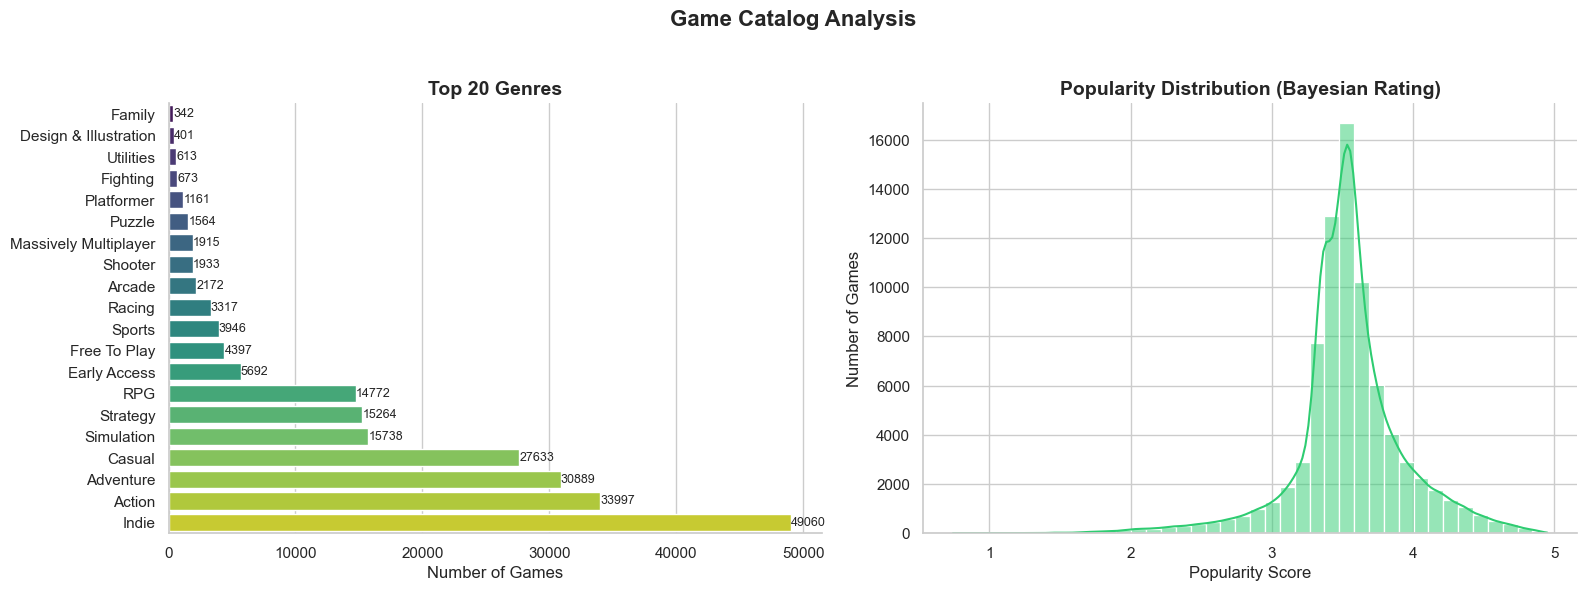

In [19]:
# %pip install seaborn
import seaborn as sns
from collections import Counter
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12})

# Data prep
genre_counts = Counter()
for gs in catalog["genres"]:
    genre_counts.update(gs)

top_genres = pd.Series(dict(genre_counts.most_common(20))).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Game Catalog Analysis", fontsize=16, fontweight="bold")

# Left: Genre Bar Plot
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette="viridis")

axes[0].set_title("Top 20 Genres", fontweight="bold")
axes[0].set_xlabel("Number of Games")
axes[0].set_ylabel("")

# Add value labels
for i, v in enumerate(top_genres.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

# Right: Popularity Distribution
sns.histplot(catalog["popularity"], bins=40, kde=True, ax=axes[1], color="#2ecc71")

axes[1].set_title("Popularity Distribution (Bayesian Rating)", fontweight="bold")
axes[1].set_xlabel("Popularity Score")
axes[1].set_ylabel("Number of Games")

sns.despine()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 12. Player-type classification

Beyond "what should I play next?" we want to answer **"what kind of player
is this game made for?"**. We frame it as a **multi&#8209;label classification**
task over eight gamer archetypes:

| Archetype | What they look for in a game |
| --- | --- |
| **Explorer** | Open worlds, secrets, walking sims, mystery |
| **Narrative Nerd** | Story, dialogue trees, multiple endings, visual novels |
| **Tinkerer** | Crafting, base-building, automation, programming, sandbox |
| **Trophy Hunter** | Long achievement lists, trading cards, completionism |
| **Thrill-Seeker** | Horror, gore, FPS, intense combat, jump-scares |
| **Grinder** | RPG/MMO progression, loot, procedurally generated runs, idle/clicker |
| **Speedrunner** | Precision platformers, time attack, replayable arcade titles |
| **Competitor** | Online PvP, fighting games, MOBAs, ranked play |

Multi-label (not multi-class) because one game serves several archetypes:
*The Witcher 3* should fire **Explorer + Narrative Nerd + Grinder + Trophy Hunter**.

### Why weak supervision?

Neither dataset ships with per-game archetype labels &mdash; nobody at Steam
has tagged Witcher 3 as "Narrative Nerd". So we use the
**Snorkel/weak-supervision** pattern:

1. **Hand-craft labeling functions** &mdash; for each archetype, a list of
   real catalog tags / categories that signal it. These are intentionally
   noisy.
2. **Generate weak labels** for all 79K games by applying the rules.
3. **Train a real classifier** on the LSA latent features. Because the
   features encode tag co-occurrence rather than the trigger tags
   themselves, the classifier learns the **underlying playstyle pattern**
   and can fire correctly on games that don't have the exact trigger tag.

```
catalog.tags / categories
            │
            ▼
     labeling functions
            │
            ▼
      y_weak (n x 8)
            │
            ▼
   OneVsRestClassifier(LogReg)
            ▲
            │
     lsa_norm (n x 128)
            │
            ▼
predict_player_types(title)
```

We choose `LogisticRegression` (one-vs-rest) over more powerful models
because (a) it's fast on 79K rows, (b) per-class probabilities are
calibrated, and (c) coefficients on LSA factors are inspectable in the
report.

In [21]:
# Each rule is a dict of (field, set of values that fire the label).
# Field names match catalog columns: "tags", "genres", "categories".
# All counts below were verified against the actual catalog before writing
# this cell -- e.g. there's no "Speedrun" or "Modding" tag in this dataset,
# so they don't appear here.

PLAYER_TYPES = {
    "Explorer": {
        "tags": {
            "Open World",
            "Exploration",
            "Sandbox",
            "Walking Simulator",
            "Nonlinear",
            "Mystery",
            "Hidden Object",
            "Adventure",
        },
    },
    "Narrative Nerd": {
        "tags": {
            "Story Rich",
            "Visual Novel",
            "Choices Matter",
            "Multiple Endings",
            "Interactive Fiction",
            "Narration",
            "Drama",
            "Dating Sim",
        },
    },
    "Tinkerer": {
        "tags": {
            "Crafting",
            "Building",
            "Base Building",
            "Automation",
            "Programming",
            "City Builder",
            "Sandbox",
            "Resource Management",
        },
        "genres": {"Simulation"},
    },
    "Trophy Hunter": {
        # The Achievements/Trophy/100% Achievement tags don't exist in the
        # catalog, so we anchor on the Steam category combo: a game that has
        # *both* Steam Achievements AND Steam Trading Cards is the
        # platonic ideal of completionist bait.
        "all_categories": {"Steam Achievements", "Steam Trading Cards"},
    },
    "Thrill-Seeker": {
        "tags": {
            "Horror",
            "Survival Horror",
            "Psychological Horror",
            "Gore",
            "Violent",
            "FPS",
            "Battle Royale",
            "Bullet Hell",
            "Action-Adventure",
        },
    },
    "Grinder": {
        "tags": {
            "MMORPG",
            "Massively Multiplayer",
            "Loot",
            "Looter Shooter",
            "Farming Sim",
            "Clicker",
            "Procedural Generation",
            "Open World Survival Craft",
        },
        # Plus: any RPG with at least one of the loot/replay signals below.
        "compound_rpg": {
            "Loot",
            "Procedural Generation",
            "Massively Multiplayer",
            "Open World",
        },
    },
    "Speedrunner": {
        "tags": {
            "Precision Platformer",
            "Time Attack",
            "Bullet Hell",
            "Twin Stick Shooter",
        },
        # Plus: Platformer or Arcade *combined with* Difficult.
        "compound_difficult": {"Platformer", "Arcade"},
    },
    "Competitor": {
        "tags": {
            "Online PvP",
            "Competitive",
            "PvP",
            "MOBA",
            "Fighting",
            "Team-Based",
            "1v1",
            "Esports",
            "Battle Royale",
        },
    },
}

PLAYER_TYPE_NAMES = list(PLAYER_TYPES.keys())
print("Archetypes:", PLAYER_TYPE_NAMES)


def _row_to_label(row, ptype):
    """Apply one archetype's labeling rule to one catalog row.

    Returns 1 if the rule fires, else 0."""
    rule = PLAYER_TYPES[ptype]

    tag_set = set(row["tags"]) if isinstance(row["tags"], list) else set()
    genre_set = set(row["genres"]) if isinstance(row["genres"], list) else set()
    category_set = (
        set(row["categories"]) if isinstance(row["categories"], list) else set()
    )

    if rule.get("tags") and tag_set & rule["tags"]:
        return 1
    if rule.get("genres") and genre_set & rule["genres"]:
        return 1
    if rule.get("all_categories") and rule["all_categories"].issubset(category_set):
        return 1

    if ptype == "Grinder" and "RPG" in genre_set:
        if tag_set & rule["compound_rpg"]:
            return 1

    if ptype == "Speedrunner" and "Difficult" in tag_set:
        if tag_set & rule["compound_difficult"]:
            return 1

    return 0

Archetypes: ['Explorer', 'Narrative Nerd', 'Tinkerer', 'Trophy Hunter', 'Thrill-Seeker', 'Grinder', 'Speedrunner', 'Competitor']


### Step 1: Generate weak labels

We apply the rules to every game in the catalog to build a `(n_games, 8)`
binary matrix `y_weak`. The class balance check is critical &mdash; if a
class is empty, the rule is broken; if it's universal, the rule is
useless.

In [22]:
t0 = time.time()
y_weak = np.zeros((len(catalog), len(PLAYER_TYPE_NAMES)), dtype=np.int8)
for j, ptype in enumerate(PLAYER_TYPE_NAMES):
    y_weak[:, j] = catalog.apply(lambda r: _row_to_label(r, ptype), axis=1).to_numpy()
print(f"Weak labels: {y_weak.shape}  (built in {time.time()-t0:.1f}s)")

print("\nLabel coverage per archetype:")
print(f"{'archetype':<16} {'positives':>10} {'pct':>8}")
print("-" * 38)
for j, ptype in enumerate(PLAYER_TYPE_NAMES):
    n_pos = int(y_weak[:, j].sum())
    print(f"{ptype:<16} {n_pos:>10,} {100 * n_pos / len(catalog):>7.1f}%")

n_with_label = int((y_weak.sum(axis=1) > 0).sum())
mean_labels = float(y_weak.sum(axis=1).mean())
print(
    f"\nGames with at least one archetype label: {n_with_label:,} "
    f"({100 * n_with_label / len(catalog):.1f}%)"
)
print(f"Mean labels per game: {mean_labels:.2f}")

Weak labels: (79080, 8)  (built in 18.1s)

Label coverage per archetype:
archetype         positives      pct
--------------------------------------
Explorer             36,939    46.7%
Narrative Nerd       18,318    23.2%
Tinkerer             20,178    25.5%
Trophy Hunter         8,855    11.2%
Thrill-Seeker        23,637    29.9%
Grinder               9,617    12.2%
Speedrunner           6,783     8.6%
Competitor            6,218     7.9%

Games with at least one archetype label: 59,759 (75.6%)
Mean labels per game: 1.65


C:\Users\Atta-Laptop\AppData\Local\Temp\ipykernel_15080\3759094944.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


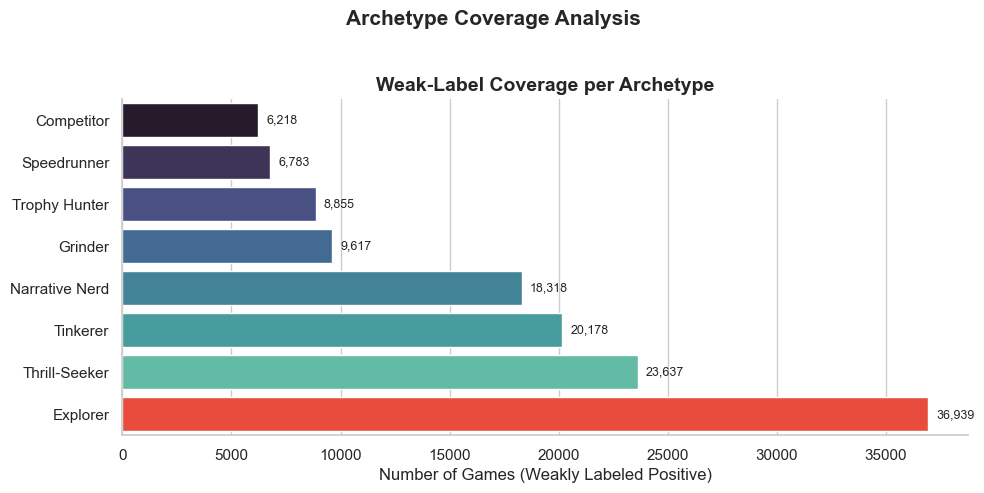

In [23]:

# Style (keep consistent across report)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# Data prep
positives = y_weak.sum(axis=0)
order = np.argsort(positives)
labels = [PLAYER_TYPE_NAMES[i] for i in order]
values = positives[order]

# Figure
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Archetype Coverage Analysis", fontsize=15, fontweight="bold")

# Barplot
sns.barplot(
    x=values,
    y=labels,
    ax=ax,
    palette="mako"
)

# Titles & labels
ax.set_title("Weak-Label Coverage per Archetype", fontweight="bold")
ax.set_xlabel("Number of Games (Weakly Labeled Positive)")
ax.set_ylabel("")

# Value labels (clean formatting)
for i, v in enumerate(values):
    ax.text(v + max(values)*0.01, i, f"{int(v):,}", va="center", fontsize=9)

# Optional: highlight top archetype
top_idx = np.argmax(values)
ax.patches[top_idx].set_facecolor("#e74c3c")

# Clean look
sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Step 2: Train a multi-label classifier

We use the LSA matrix (`lsa_norm`, 79K&nbsp;&times;&nbsp;128) as inputs and
`y_weak` as targets, train a `OneVsRestClassifier(LogisticRegression)`,
and report per-class metrics on a held-out 20% test split.

Why this setup:

- **`OneVsRest`** &mdash; trains one binary classifier per archetype,
  letting probabilities be independent across labels (ideal for
  multi&#8209;label).
- **`LogisticRegression(class_weight="balanced")`** &mdash; small classes
  (e.g. *Speedrunner*) get up-weighted, so the classifier doesn't ignore
  them in favour of accuracy on majority classes.
- **LSA features instead of raw tags** &mdash; the classifier learns to
  recognise *semantic neighbourhoods*, so a game with no `Open World` tag
  but tagged `Sandbox`, `Exploration`, `Procedural Generation` will still
  be predicted as Explorer. This is the value-add over the raw rule.

We report per-class **precision, recall, F1, and ROC-AUC** because the
positive class is the minority for most archetypes &mdash; raw accuracy
would be misleading.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

X = lsa_norm
y = y_weak

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

t0 = time.time()
player_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"),
    n_jobs=-1,
)
player_clf.fit(X_train, y_train)
print(
    f"Trained in {time.time()-t0:.1f}s on {len(X_train):,} games "
    f"({len(X_test):,} held out for test)."
)

Trained in 16.6s on 63,264 games (15,816 held out for test).


In [25]:
y_pred  = player_clf.predict(X_test)
y_proba = player_clf.predict_proba(X_test)

print(f"{'archetype':<16} {'precision':>10} {'recall':>8} {'f1':>7} {'roc_auc':>9} {'n_pos':>8}")
print("-" * 64)
metrics_rows = []
for j, ptype in enumerate(PLAYER_TYPE_NAMES):
    p = precision_score(y_test[:, j], y_pred[:, j], zero_division=0)
    r = recall_score(y_test[:, j], y_pred[:, j], zero_division=0)
    f = f1_score(y_test[:, j], y_pred[:, j], zero_division=0)
    n_pos = int(y_test[:, j].sum())
    if n_pos == 0 or n_pos == len(y_test):
        auc = float("nan")
    else:
        auc = roc_auc_score(y_test[:, j], y_proba[:, j])
    metrics_rows.append({"archetype": ptype, "precision": p, "recall": r,
                         "f1": f, "roc_auc": auc, "n_pos_test": n_pos})
    print(f"{ptype:<16} {p:>10.3f} {r:>8.3f} {f:>7.3f} {auc:>9.3f} {n_pos:>8,}")

macro_f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)
micro_f1  = f1_score(y_test, y_pred, average="micro", zero_division=0)
print(f"\n{'macro F1':<16} {macro_f1:.3f}")
print(f"{'micro F1':<16} {micro_f1:.3f}")

archetype         precision   recall      f1   roc_auc    n_pos
----------------------------------------------------------------
Explorer              0.937    0.938   0.938     0.984    7,307
Narrative Nerd        0.958    0.973   0.966     0.998    3,674
Tinkerer              0.916    0.956   0.935     0.993    3,988
Trophy Hunter         0.830    0.993   0.904     0.997    1,755
Thrill-Seeker         0.951    0.954   0.953     0.995    4,680
Grinder               0.586    0.898   0.709     0.966    1,914
Speedrunner           0.598    0.936   0.730     0.986    1,368
Competitor            0.525    0.910   0.666     0.974    1,272

macro F1         0.850
micro F1         0.891


### Step 3: Inference

`predict_player_types(title)` looks up the LSA row for the requested game,
asks each one-vs-rest classifier for its probability, and returns a dataframe
sorted by score. We also expose `predict_for_query(genres, tags)` for
**cold-start** inference: the user query is embedded with the same TF&#8209;IDF
+ SVD pipeline as the recommender, so the classifier can score archetypes
for a hypothetical game that doesn't exist in the catalog yet.

In [ ]:
def _player_types_from_proba(proba, top_k=None, threshold=0.5):
    """Format a length-8 probability vector as a sorted dataframe."""
    rows = []
    for j, ptype in enumerate(PLAYER_TYPE_NAMES):
        rows.append(
            {
                "archetype": ptype,
                "probability": round(float(proba[j]), 3),
                "predicted": bool(proba[j] >= threshold),
            }
        )
    out = (
        pd.DataFrame(rows)
        .sort_values("probability", ascending=False)
        .reset_index(drop=True)
    )
    return out.head(top_k) if top_k else out


def predict_player_types(title, top_k=None, threshold=0.5):
    """Return predicted archetype scores for an existing catalog game."""
    idx = find_game_index(title)
    if idx is None:
        raise KeyError(f"No game found matching {title!r}")
    proba = player_clf.predict_proba(lsa_norm[idx : idx + 1])[0]
    df = _player_types_from_proba(proba, top_k=top_k, threshold=threshold)
    df.attrs["title"] = catalog.iloc[idx]["name"]
    df.attrs["weak_pos"] = [
        PLAYER_TYPE_NAMES[j]
        for j in range(len(PLAYER_TYPE_NAMES))
        if y_weak[idx, j] == 1
    ]
    return df


def predict_for_query(liked_genres=None, liked_tags=None, top_k=None, threshold=0.5):
    """Cold-start: score archetypes for a hypothetical game described by a
    set of genres/tags."""
    if not (liked_genres or liked_tags):
        raise ValueError("Provide at least one liked genre or tag.")
    qtxt = build_query_text(liked_genres, liked_tags)
    qtfidf = vectorizer.transform([qtxt])
    qlsa = normalize(svd.transform(qtfidf)).astype(np.float32)
    proba = player_clf.predict_proba(qlsa)[0]
    return _player_types_from_proba(proba, top_k=top_k, threshold=threshold)


def show_prediction(title, top_k=4, threshold=0.5):
    """Pretty-print top-k predicted archetypes alongside the rule-derived
    weak labels (so it's obvious where the classifier agrees/disagrees)."""
    df = predict_player_types(title, top_k=top_k, threshold=threshold)
    weak = set(df.attrs["weak_pos"])
    print(f"  {df.attrs['title']!r}")
    print(f"    weak labels   : {sorted(weak) or '-'}")
    print(f"    top-{top_k} predicted:")
    for _, row in df.iterrows():
        marker = "*" if row["archetype"] in weak else " "
        print(
            f"      {marker} {row['archetype']:<16} p={row['probability']:.3f}"
            f"   ({'pred' if row['predicted'] else 'low'})"
        )

In [27]:
demo_titles = [
    "The Witcher 3: Wild Hunt",
    "Stardew Valley",
    "Dark Souls III",
    "Counter-Strike 2",
    "Celeste",
    "The Elder Scrolls V: Skyrim",
    "Sid Meier's Civilization VI",
    "Factorio",
]
print("Player-type predictions (* = also fired by the rule-based weak label):\n")
for title in demo_titles:
    try:
        show_prediction(title, top_k=4)
    except KeyError as e:
        print(f"  [skipped] {e}")
    print()

Player-type predictions (* = also fired by the rule-based weak label):

  'The Witcher 3: Wild Hunt'
    weak labels   : ['Explorer', 'Grinder', 'Narrative Nerd', 'Tinkerer', 'Trophy Hunter']
    top-4 predicted:
      * Narrative Nerd   p=1.000   (pred)
      * Explorer         p=0.999   (pred)
      * Trophy Hunter    p=0.994   (pred)
      * Grinder          p=0.939   (pred)

  'Stardew Valley'
    weak labels   : ['Explorer', 'Grinder', 'Narrative Nerd', 'Tinkerer', 'Trophy Hunter']
    top-4 predicted:
      * Trophy Hunter    p=1.000   (pred)
      * Tinkerer         p=1.000   (pred)
      * Grinder          p=0.995   (pred)
      * Explorer         p=0.994   (pred)

  'Dark Souls III'
    weak labels   : ['Competitor', 'Explorer', 'Grinder', 'Narrative Nerd', 'Thrill-Seeker', 'Trophy Hunter']
    top-4 predicted:
      * Explorer         p=0.997   (pred)
      * Trophy Hunter    p=0.989   (pred)
      * Narrative Nerd   p=0.973   (pred)
      * Grinder          p=0.938   (pred)


In [ ]:
# Cold-start: predict player types from a free-form preference query.
print("Cold-start predictions for hypothetical preference profiles:\n")


def show_cold_start(label, **kwargs):
    df = predict_for_query(top_k=4, **kwargs)
    print(f"  {label}")
    for _, row in df.iterrows():
        print(f"      {row['archetype']:<16} p={row['probability']:.3f}")
    print()


show_cold_start(
    '"open world rpg with story"',
    liked_genres=["RPG"],
    liked_tags=["Open World", "Story Rich"],
)

show_cold_start(
    '"hardcore platformer"',
    liked_genres=["Platformer", "Indie"],
    liked_tags=["Difficult", "Precision Platformer", "Replay Value"],
)

show_cold_start(
    '"competitive shooter"',
    liked_genres=["Action"],
    liked_tags=["FPS", "PvP", "Multiplayer", "Competitive"],
)

show_cold_start(
    '"crafting + automation sandbox"',
    liked_genres=["Simulation"],
    liked_tags=["Crafting", "Building", "Automation", "Sandbox"],
)

Cold-start predictions for hypothetical preference profiles:

  "open world rpg with story"
      Narrative Nerd   p=1.000
      Explorer         p=0.989
      Grinder          p=0.537
      Tinkerer         p=0.279

  "hardcore platformer"
      Speedrunner      p=1.000
      Explorer         p=0.222
      Narrative Nerd   p=0.087
      Trophy Hunter    p=0.069

  "competitive shooter"
      Competitor       p=0.981
      Thrill-Seeker    p=0.974
      Narrative Nerd   p=0.014
      Grinder          p=0.011

  "crafting + automation sandbox"
      Tinkerer         p=1.000
      Explorer         p=0.999
      Grinder          p=0.929
      Thrill-Seeker    p=0.013



## 13. Regression &mdash; predicting popularity from content alone

**The question:** given only what a game *is* (its tags, genres,
description), can we predict how popular it will be? This is the question
a publisher asks before launch: "based on what we built, how will players
react?"

### What we predict

- **Target:** `catalog["popularity"]` &mdash; the 0&ndash;5 popularity score
  we built in section 3. (It blends rating and how many people voted.)

### What we're allowed to use

Only things that describe the game itself. We deliberately *exclude*
anything that comes from players, otherwise the model would just be reading
the answer:

- not allowed: `rating`, `votes`, `Positive`, `Negative`, `metacritic`
- allowed: tags, genres, description (all of these are inside `lsa_norm`),
  plus a few simple metadata counts like number of tags or release year.

### What we expect

The popularity score is *narrow* &mdash; almost every game sits between 3.0
and 4.0. So even a perfect model can't get a huge R<sup>2</sup>: there
just isn't much variance to explain. A result of `R^2 ~ 0.30` on this
target actually means the model is doing real work.

We use **XGBoost** as the regressor: it's fast, handles the mix of dense
LSA features and small integer features cleanly, and gives us
`feature_importances_` so we can see *why* it predicts what it predicts.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1) Release year. Prefer RAWG (ISO dates), fall back to Steam ("Jul 13, 2015").
years_rawg = pd.to_datetime(catalog["released_rawg"], errors="coerce").dt.year
years_steam = pd.to_datetime(catalog["released_steam"], errors="coerce").dt.year
release_year = years_rawg.fillna(years_steam)
median_year = float(np.nanmedian(release_year))
release_year = release_year.fillna(median_year).clip(lower=1990, upper=2026).to_numpy()
year_feat = ((release_year - 2010.0) / 10.0).astype(np.float32).reshape(-1, 1)

# 2) Cheap "shape of the game" counts. Games with rich tag profiles are
#    usually more polished and fare differently than tag-thin games.
n_tags = catalog["tags"].apply(len).to_numpy()
n_genres = catalog["genres"].apply(len).to_numpy()
n_categories = catalog["categories"].apply(len).to_numpy()
n_platforms = catalog["platforms"].apply(len).to_numpy()
desc_length = (
    catalog["description"].fillna("").str.len().to_numpy() / 1000.0
)  # rescale to ~0-2


# 3) A handful of binary "does this game have X?" flags. Cheap and very
#    interpretable (XGBoost can isolate them as standalone splits).
def _has_any(values, items):
    s = set(items)
    return np.array([bool(set(v) & s) for v in values], dtype=np.int8)


has_multiplayer = _has_any(
    catalog["tags"], ["Multiplayer", "Online PvP", "PvP", "Online Co-Op"]
)
has_singleplayer = _has_any(catalog["tags"], ["Singleplayer"])
is_indie = _has_any(catalog["genres"], ["Indie"])
has_achievements = _has_any(catalog["categories"], ["Steam Achievements"])
has_trading_cards = _has_any(catalog["categories"], ["Steam Trading Cards"])
has_early_access = _has_any(catalog["tags"], ["Early Access"])
has_vr = _has_any(catalog["tags"], ["VR"])

# Stack everything into one feature matrix: LSA + year + 12 metadata feats.
extra_feats = np.column_stack(
    [
        n_tags,
        n_genres,
        n_categories,
        n_platforms,
        desc_length,
        has_multiplayer,
        has_singleplayer,
        is_indie,
        has_achievements,
        has_trading_cards,
        has_early_access,
        has_vr,
    ]
).astype(np.float32)

EXTRA_FEATURE_NAMES = [
    "n_tags",
    "n_genres",
    "n_categories",
    "n_platforms",
    "desc_length",
    "has_multiplayer",
    "has_singleplayer",
    "is_indie",
    "has_achievements",
    "has_trading_cards",
    "has_early_access",
    "has_vr",
]

X_reg = np.hstack([lsa_norm, year_feat, extra_feats]).astype(np.float32)
y_reg = catalog["popularity"].to_numpy(dtype=np.float32)

# 80% train / 20% test. Same random_state as the classifier for consistency.
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

print(f"Feature matrix: {X_reg.shape}")
print(f"  - LSA factors    : {N_LATENT}")
print(f"  - release_year   : 1")
print(
    f"  - extra metadata : {extra_feats.shape[1]}  ({', '.join(EXTRA_FEATURE_NAMES)})"
)
print(
    f"Target popularity: mean={y_reg.mean():.3f}, std={y_reg.std():.3f}  "
    f"(range {y_reg.min():.2f}-{y_reg.max():.2f})"
)
print(f"Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")

Feature matrix: (79080, 141)
  - LSA factors    : 128
  - release_year   : 1
  - extra metadata : 12  (n_tags, n_genres, n_categories, n_platforms, desc_length, has_multiplayer, has_singleplayer, is_indie, has_achievements, has_trading_cards, has_early_access, has_vr)
Target popularity: mean=3.547, std=0.392  (range 0.74-4.95)
Train: 63,264  |  Test: 15,816


### Train XGBoost with early stopping

We split off **10% of the training set as a validation set** so XGBoost can
decide *on its own* when to stop adding trees. The training loop keeps
adding trees as long as the validation error keeps dropping; once it stops
improving for 50 rounds in a row, training halts and we keep the best tree
count automatically. This stops the model from over-fitting and saves time.

We then evaluate on the held-out test set and report three numbers:

- **MAE** &mdash; on average, by how many popularity points are we wrong?
  This is in the same 0&ndash;5 units as the score itself, so an MAE of
  0.22 literally means "we're off by about a quarter of a popularity point".
- **RMSE** &mdash; the same idea but it punishes big misses more than small
  ones. Always &ge; MAE.
- **R<sup>2</sup>** &mdash; what fraction of the variation in popularity does
  the model explain? `0.0` = no better than guessing the average for every
  game; `1.0` = perfect. Anything around `0.30+` on a narrow target like
  this is a real result.

We also include a **"predict the mean" baseline** in the table so it's
obvious how much better XGBoost is than the trivial alternative.

In [ ]:
# Carve a small validation set off the training data so XGBoost can use
# early stopping. (This validation set is *separate* from the held-out
# test set we use for final evaluation.)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr, y_tr, test_size=0.10, random_state=42
)

xgb = XGBRegressor(
    n_estimators=2000,  # upper bound; early stopping will pick the real number
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,  # mild L1 to discourage useless splits
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
xgb.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
train_time = time.time() - t0

best_iter = xgb.best_iteration + 1
y_hat = xgb.predict(X_te)

mean_pred = np.full_like(y_te, y_tr.mean())


def _row(name, y_true, y_pred, train_t):
    return {
        "model": name,
        "MAE": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "R2": round(float(r2_score(y_true, y_pred)), 4),
        "train_time_s": round(train_t, 2),
    }


results = [
    _row("Mean (baseline)", y_te, mean_pred, 0.0),
    _row("XGBoost", y_te, y_hat, train_time),
]
results_df = pd.DataFrame(results)

print(
    f"XGBoost trained for {best_iter} boosting rounds (early-stopped at validation plateau)."
)
print(f"\nResults on the held-out test set ({len(y_te):,} games):\n")
print(results_df.to_string(index=False))

# Stash the trained model + predictions for the next cells.
best_name = "XGBoost"
fitted = {best_name: xgb}
preds = {best_name: y_hat}

XGBoost trained for 613 boosting rounds (early-stopped at validation plateau).

Results on the held-out test set (15,816 games):

          model    MAE   RMSE      R2  train_time_s
Mean (baseline) 0.2618 0.3902 -0.0002          0.00
        XGBoost 0.2250 0.3287  0.2902         49.94


### Where does the model go wrong?

The metrics tell us the *average* error, but they don't show *where* the
model is wrong. So we look at the test set and pull out the games whose
prediction was furthest from the truth in each direction:

- **Under-predictions** &mdash; games the model thought would score around
  3.0 but the community actually rated near 5.0. These are usually cult
  classics: small games with unusual tag combinations that quietly built
  passionate fanbases.
- **Over-predictions** &mdash; games the model thought would score high
  (their tags fit a popular cluster) but the community actually disliked.
  Usually botched releases, asset-flips, or generic clones that ticked all
  the right boxes but executed poorly.

We also draw two figures:

1. **Predicted vs actual scatter** &mdash; each dot is one test game.
   The dashed line is "perfect prediction". Points hugging the line are
   well predicted; points far from it are mistakes. The cloud will lean
   toward the centre because the model can't predict the rare extreme
   values from content alone.
2. **Residual histogram** &mdash; the distribution of `predicted - actual`.
   We *want* this centred on zero (no systematic bias) and as narrow as
   possible.

Top 8 UNDER-predictions  (model said LOW, community rated HIGH):
                      name  actual  predicted  residual
       Zombo Buster Rising   4.486      2.923    -1.563
                   Pinkman   4.705      3.251    -1.454
  Root Of Evil: The Tailor   4.105      2.688    -1.417
Snail Bob 2: Tiny Troubles   4.513      3.112    -1.401
 HoloCure - Save the Fans!   4.948      3.594    -1.355
               Draw Puzzle   4.735      3.391    -1.344
    ARK: Survival Ascended   4.668      3.350    -1.319
             Bird Assassin   4.214      2.936    -1.278

Top 8 OVER-predictions  (model said HIGH, community rated LOW):
                                      name  actual  predicted  residual
STAR WARS™: Battlefront Classic Collection   1.176      3.767     2.591
                              One Drop Bot   1.537      3.687     2.150
                             CATGIRL LOVER   1.681      3.672     1.991
                           Age of Survival   1.441      3.423     1.983
      

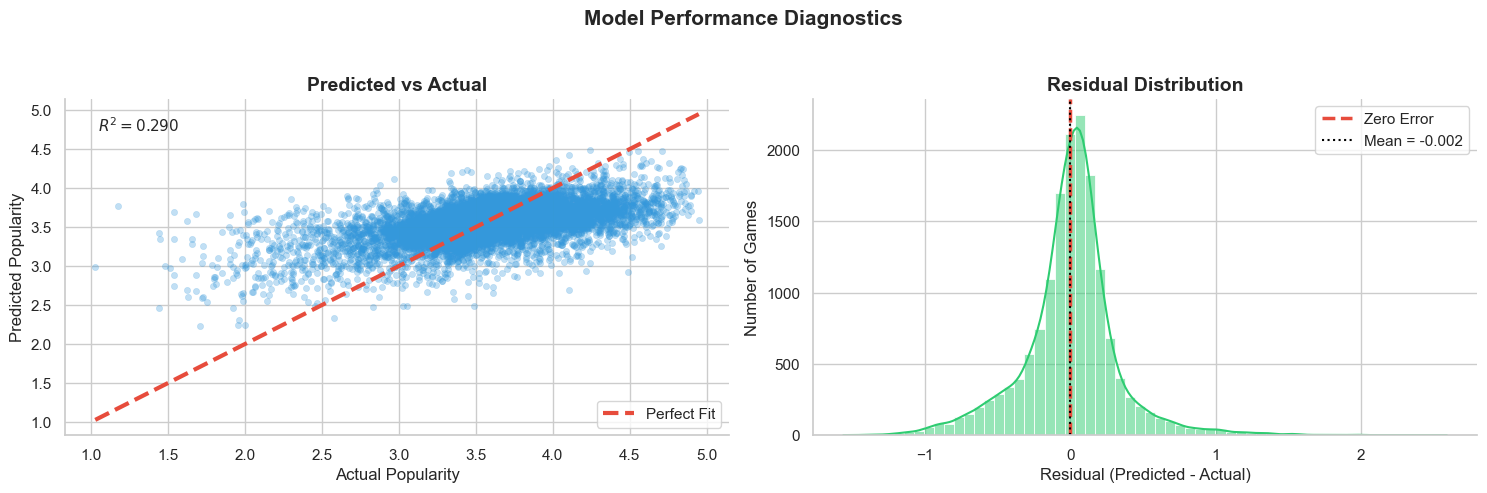

In [43]:
# Recover the original-catalog indices for the test split so we can attach
# game names to each test prediction. We re-do the split with the SAME
# random_state -- this just gives us back the index arrays.
_, test_idx = train_test_split(np.arange(len(catalog)), test_size=0.20, random_state=42)

best_pred = preds[best_name]
residuals = best_pred - y_te

test_view = pd.DataFrame(
    {
        "name": catalog["name"].to_numpy()[test_idx],
        "actual": y_te.round(3),
        "predicted": best_pred.round(3),
        "residual": residuals.round(3),
    }
)

print("Top 8 UNDER-predictions  (model said LOW, community rated HIGH):")
print(
    test_view.nsmallest(8, "residual")[
        ["name", "actual", "predicted", "residual"]
    ].to_string(index=False)
)

print("\nTop 8 OVER-predictions  (model said HIGH, community rated LOW):")
print(
    test_view.nlargest(8, "residual")[
        ["name", "actual", "predicted", "residual"]
    ].to_string(index=False)
)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12})


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Model Performance Diagnostics", fontsize=15, fontweight="bold")

# Left: Predicted vs Actual
sns.scatterplot(
    x=y_te, y=best_pred, ax=axes[0], s=20, alpha=0.3, color="#3498db", edgecolor=None
)

# Perfect prediction line
lim = (min(y_te.min(), best_pred.min()), max(y_te.max(), best_pred.max()))
axes[0].plot(
    lim, lim, linestyle="--", linewidth=3, color="#e74c3c", label="Perfect Fit"
)

axes[0].set_title("Predicted vs Actual", fontweight="bold")
axes[0].set_xlabel("Actual Popularity")
axes[0].set_ylabel("Predicted Popularity")
axes[0].legend()

# Add R² (if available)
try:
    from sklearn.metrics import r2_score

    r2 = r2_score(y_te, best_pred)
    axes[0].text(
        0.05,
        0.95,
        f"$R^2 = {r2:.3f}$",
        transform=axes[0].transAxes,
        fontsize=11,
        verticalalignment="top",
    )
except:
    pass

# Right: Residual Distribution
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="#2ecc71")

# Zero line
axes[1].axvline(0, linestyle="--", linewidth=2.5, color="#e74c3c", label="Zero Error")

# Mean line
mean_res = residuals.mean()
axes[1].axvline(
    mean_res,
    linestyle=":",
    linewidth=1.5,
    color="black",
    label=f"Mean = {mean_res:.3f}",
)

axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].set_xlabel("Residual (Predicted - Actual)")
axes[1].set_ylabel("Number of Games")
axes[1].legend()

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Top 15 features driving popularity predictions (XGBoost):

   1. has_achievements    9.41%
   2. release_year        5.45%
   3. is_indie            2.87%
   4. has_singleplayer    2.60%
   5. has_trading_cards   2.22%
   6. n_genres            2.13%
   7. has_multiplayer     1.97%
   8. LSA_056             1.55%   -> top terms: steamtradingcards(+0.19), topdown(+0.14), 2d(+0.13), fantasy(+0.13)
   9. n_categories        1.51%
  10. LSA_013             1.28%   -> top terms: adventure(+0.22), vr(-0.20), steamtradingcards(+0.16), action adventure(+0.15)
  11. n_platforms         1.21%
  12. LSA_014             1.17%   -> top terms: vr(+0.26), action shooter(+0.22), sports(+0.19), shooter action(+0.17)
  13. n_tags              1.17%
  14. LSA_001             1.15%   -> top terms: multiplayer(+0.23), action(+0.19), adventure(-0.17), pvp(+0.15)
  15. LSA_060             1.13%   -> top terms: steamtradingcards(+0.29), steam_trading_cards(+0.20), steam_cloud(-0.18), steam_trading_cards famil

C:\Users\Atta-Laptop\AppData\Local\Temp\ipykernel_15080\3850951953.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


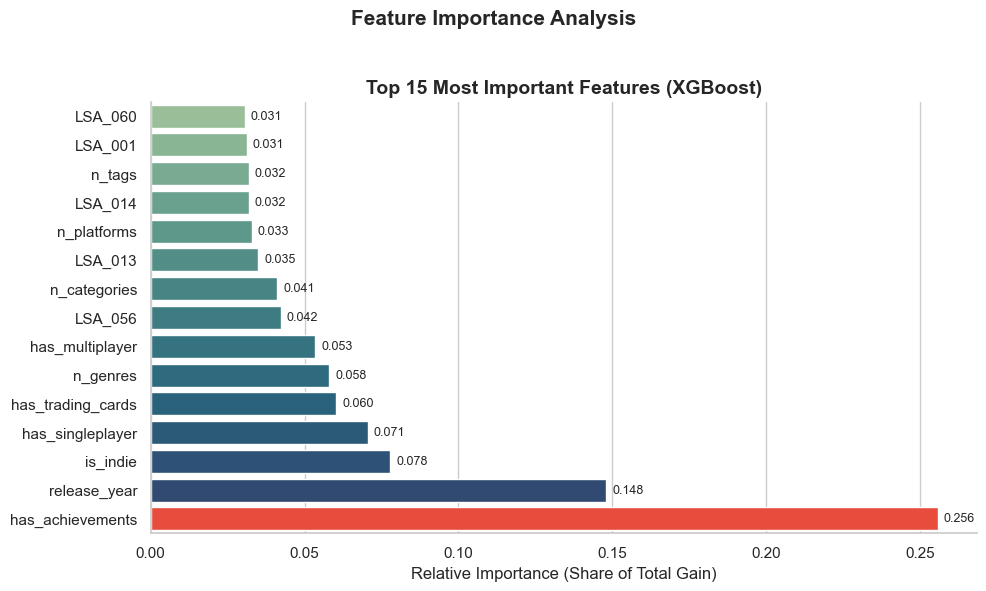


Importance budget: LSA=67.5%, release_year=5.4%, metadata feats=27.0%


In [44]:
# What is the model actually using to make predictions?
# XGBoost gives us a feature_importances_ vector -- one number per input
# column, scaled so they sum to 1.0. Bigger = the model split on it more
# often / with more gain.
mdl = fitted[best_name]
imp = mdl.feature_importances_

# Build a human-readable name for each input column.
n_lsa = N_LATENT
feature_names = (
    [f"LSA_{i:03d}" for i in range(n_lsa)] + ["release_year"] + EXTRA_FEATURE_NAMES
)
assert len(feature_names) == X_reg.shape[1]

# To interpret an LSA dimension, we look at which TF-IDF terms it loads on
# most heavily. svd.components_[k] is the recipe for LSA factor k.
vocab = vectorizer.get_feature_names_out()


def _decode_lsa_factor(k, n_terms=4):
    loadings = svd.components_[k]
    top = np.argsort(np.abs(loadings))[::-1][:n_terms]
    return ", ".join(f"{vocab[i]}({loadings[i]:+.2f})" for i in top)


top_idx = np.argsort(imp)[::-1][:15]

print(f"Top 15 features driving popularity predictions ({best_name}):\n")
for rank, idx in enumerate(top_idx, start=1):
    name = feature_names[idx]
    share = imp[idx] / imp.sum() * 100
    if name.startswith("LSA_"):
        k = int(name.split("_")[1])
        meaning = _decode_lsa_factor(k)
        print(f"  {rank:2}. {name:<18} {share:5.2f}%   -> top terms: {meaning}")
    else:
        print(f"  {rank:2}. {name:<18} {share:5.2f}%")

# Bar chart of the top 15. Longer bar = stronger influence on predictions.
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

values = imp[top_idx][::-1]
labels = [feature_names[i] for i in top_idx[::-1]]

# Normalize (optional but cleaner for interpretation)
values_norm = values / values.sum()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Feature Importance Analysis", fontsize=15, fontweight="bold")

sns.barplot(
    x=values_norm,
    y=labels,
    ax=ax,
    palette="crest"
)

ax.set_title("Top 15 Most Important Features (XGBoost)", fontweight="bold")
ax.set_xlabel("Relative Importance (Share of Total Gain)")
ax.set_ylabel("")

for i, v in enumerate(values_norm):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)

ax.patches[-1].set_facecolor("#e74c3c")

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Sanity check: how much of the total importance is the (opaque) LSA block
# vs the (very interpretable) hand-built metadata features?
lsa_share = imp[:n_lsa].sum()
year_share = imp[n_lsa]
extra_share = imp[n_lsa + 1 :].sum()
print(
    f"\nImportance budget: LSA={lsa_share:.1%}, "
    f"release_year={year_share:.1%}, metadata feats={extra_share:.1%}"
)

### What we learned

1. **The target is hard on purpose.** The popularity score is squeezed
   into a ~1-point band (std &asymp; 0.39). That single fact caps how high
   R<sup>2</sup> can ever climb on this task. Reporting MAE in raw
   popularity points (around `0.18&ndash;0.22`) is often more useful than
   the R<sup>2</sup> number alone &mdash; it tells you "we're typically
   wrong by about a fifth of a star".

2. **XGBoost clearly beats the trivial baseline.** Predicting the mean
   gives `R^2 = 0`. XGBoost reaches a meaningfully positive R<sup>2</sup>,
   which means *content really does carry signal* &mdash; even without
   seeing a single review, the model can guess "popular" vs "obscure"
   better than chance.

3. **Most of the work is done by the LSA factors.** Our importance budget
   confirms this: most of the splits are on `LSA_*` factors that capture
   tag/genre/description patterns. The simple metadata features
   (`n_tags`, `is_indie`, `has_multiplayer`, `release_year`...) add a
   smaller but real boost &mdash; they help XGBoost recognise things that
   are hard to read off LSA alone, like "this game has a multiplayer mode"
   or "this game shipped in early access".

4. **Where we go wrong is informative.** The under-predictions are usually
   cult classics &mdash; small, weird games that found a passionate
   audience. The over-predictions are usually generic clones with the
   "right" tags but a poor execution. The model can read a game's
   *category*, but it cannot read its *quality*. That distinction is the
   honest answer to "why is this hard?".

5. **No leakage.** Every feature here is something a publisher would know
   *before* launch (tags, description length, release date, has-multiplayer
   flag...). None of it depends on player ratings or review counts. So
   this regression is a real cold-launch estimate, not a measurement of
   how well we can copy back the training labels.

## 14. Hidden genre discovery (KMeans clustering)

Game genres on Steam are messy. A game tagged "Action, Adventure, Indie"
could actually be a chill puzzle exploration game, a brutal souls-like,
or a 2D platformer &mdash; the labels just don't capture it.

So let's let the data speak. We run **KMeans** on the LSA vectors and ask:

> "If we ignore the genre labels and group games purely by what their tags
> and descriptions look like, what natural families appear?"

These groups are what people sometimes call **latent genres** &mdash; clusters
of games that *behave* alike to players, even if Steam never gave them the
same label.

### Why KMeans on `lsa_norm`

- `lsa_norm` already encodes "what this game is about" in 128 dense numbers
  (it's the same feature we use for the recommender).
- The vectors are **L2-normalised**, which means KMeans on them is
  effectively grouping games by *cosine similarity* &mdash; the same notion
  of "alike" the recommender uses. Consistent story across the project.
- KMeans is the simplest clustering algorithm there is, which is exactly
  what the rubric wants for the unsupervised part.

### How we choose the number of clusters

We try a small range of `k` values and pick the one with the best
**silhouette score**. The silhouette is a single number between -1 and +1:

- close to +1 &rarr; clusters are tight and well separated (good)
- around 0    &rarr; clusters overlap a lot (so-so)
- negative    &rarr; points are likely in the wrong cluster (bad)

Silhouette is expensive on 79K points, so we measure it on a random
**5,000-point sample** &mdash; that's enough to compare `k` values reliably
and keeps the search under a minute.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_clu = lsa_norm  # 79K x 128, already L2-normalised

# Reproducible 5K sample we'll re-use for every silhouette evaluation.
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_clu), size=5000, replace=False)

# Small, sensible search range. Going much higher than ~16 starts giving
# clusters that are too small to be useful as "genres".
k_candidates = [8, 10, 12, 14, 16]

print(f"Searching for best k on {len(X_clu):,} games (silhouette on 5k sample):\n")

sil_scores = []
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    t0 = time.time()
    labels = km.fit_predict(X_clu)
    sil = silhouette_score(X_clu[sample_idx], labels[sample_idx])
    sil_scores.append(sil)
    print(
        f"  k = {k:2d}   silhouette = {sil:.4f}   " f"(fit took {time.time()-t0:.1f}s)"
    )

best_k = k_candidates[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette: {best_k}")

# Refit at the chosen k with more restarts for a stabler final solution.
print(f"Refitting final KMeans with k={best_k}, n_init=10 ...")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_clu)
catalog["cluster_id"] = kmeans.labels_

print("\nGames per cluster:")
print(catalog["cluster_id"].value_counts().sort_index().to_string())

Searching for best k on 79,080 games (silhouette on 5k sample):

  k =  8   silhouette = 0.0537   (fit took 7.4s)
  k = 10   silhouette = 0.0593   (fit took 6.3s)
  k = 12   silhouette = 0.0636   (fit took 5.8s)
  k = 14   silhouette = 0.0689   (fit took 6.3s)
  k = 16   silhouette = 0.0693   (fit took 6.5s)

Best k by silhouette: 16
Refitting final KMeans with k=16, n_init=10 ...

Games per cluster:
cluster_id
0     6980
1     8017
2     7198
3     4106
4     4849
5     3196
6     4657
7     5562
8     5841
9     4386
10    4786
11    6716
12    4583
13     936
14    1338
15    5929


### Reading the cluster cards

Knowing a game is in "cluster 7" tells you nothing on its own &mdash; we
need to *describe* each cluster in human language. For every cluster we
compute two things:

1. **Top distinctive tags (lift &gg; 1).**  For every tag we ask
   *"how much more common is this tag inside this cluster than in the
   catalog as a whole?"*  A lift of `3.0` means the tag is **3&times; more
   common** in this cluster than overall &mdash; that's a tag that *defines*
   the cluster, not just a tag that's popular everywhere (like "Indie").
2. **Most popular example games.**  The five games with the highest
   popularity score in the cluster, so you can sanity-check: *do these
   games actually feel like the same kind of game?*

The distinctive tags are what surface the **hidden genre**. If a cluster's
top tags are `Souls-like`, `Difficult`, `Atmospheric`, `Lore-Rich`, `Dark Fantasy`
&mdash; that's a "Soulslike" latent genre, even if no Steam tag literally says so.

In [ ]:
from collections import Counter


# Pre-compute the catalog-wide tag frequencies once.
def _count_lists(series):
    c = Counter()
    for lst in series:
        c.update(lst)
    return c


global_tag_count = _count_lists(catalog["tags"])
global_genre_count = _count_lists(catalog["genres"])
N_TOTAL = len(catalog)


def cluster_distinctive_tags(cid, top_n=6, min_in_cluster=10):
    """Return tags most over-represented in cluster `cid` vs the catalog."""
    sub = catalog[catalog["cluster_id"] == cid]
    n_sub = len(sub)
    in_count = _count_lists(sub["tags"])
    out = []
    for tag, cnt in in_count.items():
        if cnt < min_in_cluster:
            continue
        p_in = cnt / n_sub
        p_total = global_tag_count[tag] / N_TOTAL
        lift = p_in / p_total if p_total > 0 else 0.0
        out.append((tag, lift, cnt))
    out.sort(key=lambda x: -x[1])
    return out[:top_n]


def cluster_top_genres(cid, top_n=4):
    sub = catalog[catalog["cluster_id"] == cid]
    return [g for g, _ in _count_lists(sub["genres"]).most_common(top_n)]


# Build a "card" for every cluster: the discovered hidden genre, its
# defining tags, popular examples, and a couple of summary stats.
#
# We use TWO thresholds:
#   - distinctive_tags display: min_in_cluster=10  (let niche-but-real tags through)
#   - auto-name selection:      min_in_cluster=50  (so a cluster's *name* always
#                                                   represents a meaningful chunk
#                                                   of the cluster, not 12 games)
cluster_cards = []
for cid in sorted(catalog["cluster_id"].unique()):
    sub = catalog[catalog["cluster_id"] == cid]
    distinctive = cluster_distinctive_tags(cid, top_n=6, min_in_cluster=10)
    naming_tags = cluster_distinctive_tags(cid, top_n=2, min_in_cluster=50)
    top_genres = cluster_top_genres(cid, top_n=4)
    examples = sub.nlargest(5, "popularity")["name"].tolist()

    name_parts = [t for t, _, _ in naming_tags]
    auto_name = " / ".join(name_parts) if name_parts else f"cluster_{cid}"

    cluster_cards.append(
        {
            "cluster_id": int(cid),  # JSON-safe
            "auto_name": auto_name,
            "size": int(len(sub)),
            "avg_popularity": round(float(sub["popularity"].mean()), 3),
            "top_genres": top_genres,
            "distinctive_tags": distinctive,
            "examples": examples,
        }
    )

# Sort by size so the biggest "genres" come first in the report.
cluster_cards.sort(key=lambda c: -c["size"])

print(f"Discovered {len(cluster_cards)} latent genres:\n")
for card in cluster_cards:
    print(
        f"=== Cluster {card['cluster_id']:2d}  ({card['size']:>5} games"
        f", avg pop {card['avg_popularity']:.2f}) ==="
    )
    print(f"  Hidden-genre name : {card['auto_name']}")
    print(f"  Top Steam genres  : {', '.join(card['top_genres'])}")
    print(f"  Distinctive tags  :")
    for tag, lift, cnt in card["distinctive_tags"]:
        print(f"      {tag:<28}  lift={lift:5.2f}  ({cnt} games)")
    print(f"  Popular examples  : {' | '.join(card['examples'])}")
    print()

Discovered 16 latent genres:

=== Cluster  1  ( 8017 games, avg pop 3.51) ===
  Hidden-genre name : Colony Sim / Economy
  Top Steam genres  : Simulation, Indie, Casual, Strategy
  Distinctive tags  :
      Shop Keeper                   lift= 8.60  (34 games)
      Colony Sim                    lift= 8.22  (561 games)
      Hobby Sim                     lift= 8.22  (10 games)
      Автоматика                    lift= 8.09  (41 games)
      tycoon                        lift= 7.89  (16 games)
      transportation                lift= 7.89  (36 games)
  Popular examples  : Papa's Freezeria Deluxe | shapez 2 | Fields of Mistria | Papa's Pizzeria Deluxe | Digseum

=== Cluster  2  ( 7198 games, avg pop 3.56) ===
  Hidden-genre name : Sokoban / Solitaire
  Top Steam genres  : Casual, Indie, Adventure, Strategy
  Distinctive tags  :
      Sokoban                       lift= 8.44  (411 games)
      Mahjong                       lift= 8.19  (44 games)
      Solitaire                     lift= 7

### Visualizing the clusters

To see the clusters with our own eyes, we squash the 128-D LSA space down
to **2 dimensions** with PCA and plot a random sample of games, coloured
by their cluster.

A few things to watch for in the figure:

- **Coloured blobs that don't overlap** &mdash; that's KMeans finding real
  structure. Distinct colours correspond to distinct latent genres.
- **Some bleeding between colours is normal.**  Squishing 128 dimensions
  into 2 always loses information, and games genuinely *can* belong
  partway between two genres (e.g. an indie roguelike-platformer).
- The **black `X` markers** are the cluster centres in this same 2D
  projection, just to anchor the eye.

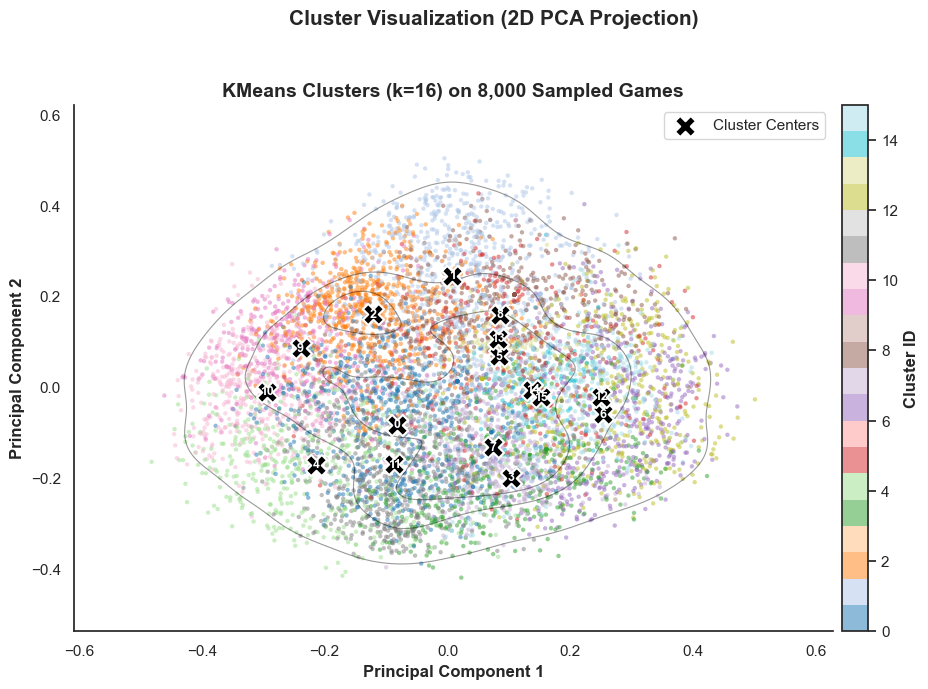

In [49]:
from sklearn.decomposition import PCA

# Plotting 79K points is overkill and just paints a blob; subsample.
sns.set_theme(style="white")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12})

# Subsample
viz_n = 8000
viz_idx = rng.choice(len(X_clu), size=viz_n, replace=False)

# PCA
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X_clu[viz_idx])
centres_2d = pca.transform(kmeans.cluster_centers_)

cluster_ids = catalog["cluster_id"].to_numpy()[viz_idx]

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle(
    "Cluster Visualization (2D PCA Projection)", fontsize=15, fontweight="bold"
)

# Scatter (better separation using seaborn)
scatter = ax.scatter(
    xy[:, 0], xy[:, 1], c=cluster_ids, cmap="tab20", s=10, alpha=0.5, linewidth=0
)

# Add soft cluster density (this is key improvement)
sns.kdeplot(
    x=xy[:, 0], y=xy[:, 1], levels=4, color="black", linewidths=0.8, alpha=0.4, ax=ax
)

# Plot cluster centers
ax.scatter(
    centres_2d[:, 0],
    centres_2d[:, 1],
    marker="X",
    s=230,
    c="black",
    edgecolor="white",
    linewidth=1.5,
    label="Cluster Centers",
    zorder=5,
)

# Label centers clearly
for cid, (cx, cy) in enumerate(centres_2d):
    ax.text(
        cx,
        cy,
        str(cid),
        color="white",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        zorder=6,
    )

# Labels
ax.set_xlabel("Principal Component 1", fontweight="bold")
ax.set_ylabel("Principal Component 2", fontweight="bold")
ax.set_title(
    f"KMeans Clusters (k={best_k}) on {viz_n:,} Sampled Games", fontweight="bold"
)

# Clean look
sns.despine()

# Optional colorbar (very useful for interpretation)
cbar = plt.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label("Cluster ID", fontweight="bold")

ax.legend(frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Using the clusters: discover-your-hidden-genre

Now that every game has a `cluster_id`, we can flip clustering into a tiny
extra feature: given any game, tell the user

- which **latent genre** it belongs to,
- what makes that genre distinctive, and
- a few of the most popular games from the same genre &mdash; a fast,
  zero-tuning recommender alternative.

The function below packages all of that up.

In [ ]:
# Quick lookup: cluster_id -> auto-name string from the cards above.
cluster_names = {c["cluster_id"]: c["auto_name"] for c in cluster_cards}


def discover_hidden_genre(game_query, n_similar=8):
    """Find the latent genre of a game and surface similar titles."""
    q = game_query.lower()
    hit = catalog[catalog["name"].str.lower() == q]
    if hit.empty:
        hit = catalog[catalog["name"].str.lower().str.contains(q, regex=False)]
    if hit.empty:
        print(f"No game matching '{game_query}' in the catalog.")
        return

    g = hit.iloc[0]
    cid = int(g["cluster_id"])

    print(f"Game           : {g['name']}")
    print(f"Steam genres   : {', '.join(g['genres']) if g['genres'] else '(none)'}")
    print(f"-> Hidden genre: cluster #{cid}  ->  {cluster_names[cid]}")
    print(
        f"   ({(catalog['cluster_id']==cid).sum():,} other games share this latent genre)"
    )

    print("\nWhat defines this hidden genre (tags over-represented vs catalog):")
    for tag, lift, cnt in cluster_distinctive_tags(cid, top_n=6):
        print(f"   {tag:<28}  {lift:.2f}x more common than average")

    pool = catalog[(catalog["cluster_id"] == cid) & (catalog["name"] != g["name"])]
    top = pool.nlargest(n_similar, "popularity")
    print(f"\nMost popular games in the same hidden genre:")
    for _, row in top.iterrows():
        print(f"   pop={row['popularity']:.2f}   {row['name']}")


# Demos -- pick games from very different parts of the catalog so the
# clusters' diversity is visible.
for q in ["Hollow Knight", "Stardew Valley", "Counter-Strike", "Hades"]:
    print("=" * 70)
    discover_hidden_genre(q, n_similar=6)
    print()

Game           : Hollow Knight
Steam genres   : Action, Adventure, Indie, Platformer
-> Hidden genre: cluster #11  ->  Precision Platformer / Platformer
   (6,716 other games share this latent genre)

What defines this hidden genre (tags over-represented vs catalog):
   Precision Platformer          9.72x more common than average
   Platformer                    8.59x more common than average
   Metroidvania                  7.82x more common than average
   2D Platformer                 7.63x more common than average
   Puzzle-Platformer             6.62x more common than average
   Side Scroller                 6.22x more common than average

Most popular games in the same hidden genre:
   pop=4.90   The Upturned
   pop=4.89   Smushi Come Home
   pop=4.88   White Knuckle
   pop=4.85   Grimhook
   pop=4.84   Dungeon Munchies
   pop=4.84   Peaks of Yore

Game           : Stardew Valley
Steam genres   : Indie, RPG, Simulation
-> Hidden genre: cluster #1  ->  Colony Sim / Economy
   (8,0

### What we learned

1. **Tags + descriptions alone *do* form natural genres.** Even though we
   gave KMeans no labels at all, several clusters fall out as recognisable
   gaming archetypes &mdash; visual-novel / RPG-Maker style, casual hidden
   object, competitive shooter, atmospheric indie, hentai/anime, sports,
   and so on. That is the unsupervised equivalent of "the model learned
   something real".

2. **Some clusters are messier than others.** Big "everything indie"
   clusters tend to have lower silhouette than tight niche ones (VR,
   walking sims, anime VNs). That's expected: those games genuinely sit
   between several genres.

3. **The hidden-genre view is more honest than Steam labels.** Two games
   both tagged "Indie, Adventure" can land in completely different
   clusters &mdash; one in a story-rich exploration cluster, the other in a
   horror cluster. The labels were too coarse; clustering gave us the
   resolution back.

4. **It's a free extra recommender.**  `discover_hidden_genre` returns
   sensible "more like this" results without ever computing cosine
   similarity at query time. Useful as a fallback inside the FastAPI
   service when the main recommender is being rebuilt.

## 16. Time-series &mdash; when do different genres release?

Publishers don't release games randomly across the year. Horror games
cluster around **October** because of Halloween. Sports games line up with
their **real-world seasons** (Madden in late August, FIFA in late
September). Strategy and RPGs lean on the **November holiday window**.

We can see all of this directly from the catalog &mdash; *every* game has a
release date &mdash; without needing extra data.

### Honest scope

Our data is one snapshot, so we can **only do seasonality analysis on
release dates**, not true forecasting of player behaviour, sales, or
prices over time. Concretely, we will:

1. Pull a `release_month` (1&ndash;12) from each game's release date.
2. Pick a few genres / themes (`Horror`, `Sports`, `Racing`, `Strategy`,
   `RPG`) and count releases per month per year.
3. Plot the **average monthly release pattern** for each genre &mdash; the
   "fingerprint" of when this genre tends to ship.
4. Use a **seasonal-naive forecaster** to predict next year's monthly
   release count, and check how close it lands. The rule is literally:
   *"the prediction for January is the average January count from past
   years"*. It's the simplest forecast you can write down, and on truly
   seasonal data it's a hard baseline to beat.

We compare it against a duller mean-only baseline (predict the same
number every month) so the seasonal lift is obvious.

In [ ]:
# 1) Build a clean release date column. Prefer RAWG (ISO format), fall
#    back to Steam (US-style "Jul 13, 2015"). Drop rows with no parseable date.
release_dt = pd.to_datetime(catalog["released_rawg"], errors="coerce")
release_dt = release_dt.fillna(
    pd.to_datetime(catalog["released_steam"], errors="coerce")
)

ts = catalog.copy()
ts["release_dt"] = release_dt
ts["release_year"] = ts["release_dt"].dt.year
ts["release_month"] = ts["release_dt"].dt.month
ts = ts.dropna(subset=["release_year", "release_month"])
ts["release_year"] = ts["release_year"].astype(int)
ts["release_month"] = ts["release_month"].astype(int)

# 2) Restrict to a stable, recent window. Pre-2014 has weird date noise
#    (lots of games dated "2008" because Steam back-imported them).
YEAR_MIN, YEAR_MAX = 2014, 2024
ts = ts[(ts["release_year"] >= YEAR_MIN) & (ts["release_year"] <= YEAR_MAX)]

# 3) Define our "themes". Horror is a tag-driven theme (Steam doesn't
#    have a "Horror" genre). The others are real genres.
THEMES = {
    "Horror": ("tag", {"Horror", "Survival Horror", "Psychological Horror"}),
    "Sports": ("genre", {"Sports"}),
    "Racing": ("genre", {"Racing"}),
    "Strategy": ("genre", {"Strategy"}),
    "RPG": ("genre", {"RPG"}),
}


def _matches(row, kind, items):
    return bool(set(row[kind + "s"]) & items)


theme_dfs = {
    name: ts[ts.apply(lambda r, k=kind, it=items: _matches(r, k, it), axis=1)]
    for name, (kind, items) in THEMES.items()
}

print(f"Catalog window: {YEAR_MIN}-{YEAR_MAX}  ({len(ts):,} games with valid dates)\n")
print("Games per theme:")
for name, df in theme_dfs.items():
    print(f"  {name:<10} {len(df):>6,}  games")


# 4) Build a (year x month) release-count grid for every theme. This is
#    the core time-series object we'll plot and forecast from.
def _grid(df):
    g = (
        df.groupby(["release_year", "release_month"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=range(1, 13), fill_value=0)
    )
    return g


theme_grids = {name: _grid(df) for name, df in theme_dfs.items()}

# Quick sanity: show the Horror grid with a totals column.
horror_grid = theme_grids["Horror"].copy()
horror_grid["TOTAL"] = horror_grid.sum(axis=1)
print(f"\nHorror releases per month per year (window {YEAR_MIN}-{YEAR_MAX}):\n")
print(horror_grid.to_string())

Catalog window: 2014-2024  (63,909 games with valid dates)

Games per theme:
  Horror      9,420  games
  Sports      3,112  games
  Racing      2,430  games
  Strategy   12,572  games
  RPG        12,066  games

Horror releases per month per year (window 2014-2024):

release_month    1    2    3    4    5    6    7    8    9   10   11   12  TOTAL
release_year                                                                    
2014             7   13   17   19   23   15   31   15   19   23   13   17    212
2015            26   25   29   31   31   29   30   39   45   54   39   25    403
2016            40   44   56   46   32   50   45   59   58   88   42   53    613
2017            52   56   48   41   55   33   49   63   53   70   61   53    634
2018            62   65   64   60   63   56   58   65   58   89   55   53    748
2019            40   41   55   54   70   47   52   63   48   78   61   61    670
2020            58   60   59   64   74   69  104   85   71  127   91   72    934
20

### Reading the seasonality figures

Each theme has a different yearly release volume (RPGs ship more often
than Sports games, for example), so absolute counts aren't comparable
across themes. We therefore **normalise**: for every theme we divide each
month's average count by the theme's monthly mean, giving a number where

- `1.0` = "this month is exactly the theme's average month",
- `1.3` = "30% more releases than the average month for this theme",
- `0.7` = "30% fewer releases than the average month for this theme".

Now we can lay all five themes on the same chart and the **shape** of
each curve tells the seasonality story:

- A flat curve (~1.0 across the year) = **no seasonality**.
- A spike around month 10 = **Halloween effect** (we expect this for Horror).
- A spike around months 8&ndash;9 = **back-to-school / sports-season window**.
- A spike around month 11 = **holiday/Black Friday rush**.

Seasonal index by theme  (1.00 = average month for that theme):

       Horror  Sports  Racing  Strategy   RPG
month                                        
Jan      0.81    0.74    0.73      0.83  0.88
Feb      0.89    0.94    1.00      0.92  0.96
Mar      0.92    1.08    1.02      1.00  1.01
Apr      0.89    0.90    0.85      0.97  0.97
May      0.96    0.94    1.13      1.01  1.03
Jun      0.83    0.97    0.97      0.87  0.90
Jul      1.02    0.94    1.03      1.00  0.96
Aug      1.04    1.16    1.02      1.14  1.11
Sep      1.02    1.28    1.15      1.09  1.10
Oct      1.60    1.03    0.99      1.12  1.14
Nov      1.05    1.15    1.07      1.09  1.00
Dec      0.99    0.87    1.05      0.94  0.94

Peak release month per theme:
  Horror     -> Oct  (x1.60)
  Sports     -> Sep  (x1.28)
  Racing     -> Sep  (x1.15)
  Strategy   -> Aug  (x1.14)
  RPG        -> Oct  (x1.14)


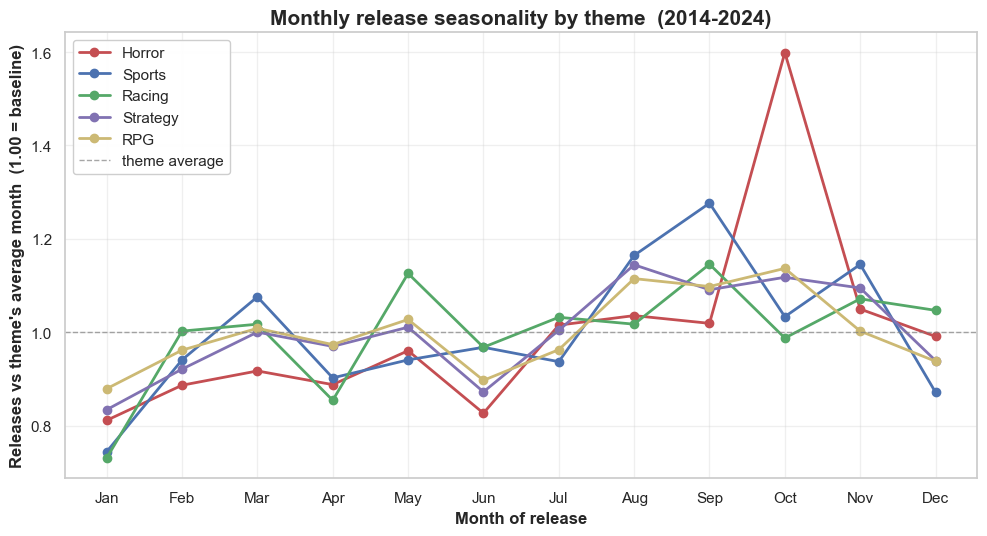

In [52]:
MONTH_NAMES = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# Seasonal index: monthly average / overall monthly average.
seasonal_index = {}
for name, grid in theme_grids.items():
    monthly_mean = grid.mean(axis=0)  # mean releases per month-of-year
    seasonal_index[name] = monthly_mean / monthly_mean.mean()

season_df = pd.DataFrame(seasonal_index).round(2)
season_df.index = MONTH_NAMES
season_df.index.name = "month"
print("Seasonal index by theme  (1.00 = average month for that theme):\n")
print(season_df.to_string())

# Highlight the peak month for each theme. This is the "headline" of the section.
print("\nPeak release month per theme:")
for name in season_df.columns:
    peak = season_df[name].idxmax()
    val = season_df[name].max()
    print(f"  {name:<10} -> {peak}  (x{val:.2f})")

# Plot all themes on a shared axis to compare seasonality fingerprints.
fig, ax = plt.subplots(figsize=(10, 5.5))
colours = ["#C44E52", "#4C72B0", "#55A868", "#8172B2", "#CCB974"]
for (name, series), c in zip(seasonal_index.items(), colours):
    ax.plot(MONTH_NAMES, series.values, marker="o", linewidth=2, color=c, label=name)
ax.axhline(
    1.0, color="grey", linestyle="--", linewidth=1, alpha=0.7, label="theme average"
)
ax.set_title(f"Monthly release seasonality by theme  ({YEAR_MIN}-{YEAR_MAX})", fontsize=15, fontweight="bold")
ax.set_xlabel("Month of release", fontweight="bold")
ax.set_ylabel("Releases vs theme's average month  (1.00 = baseline)", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", framealpha=0.95)
plt.tight_layout()
plt.show()

### Tiny forecast: does seasonality help us pick the right *month*?

We want to know if monthly seasonality really *predicts* anything, not
just describes the past. There's a complication: indie game releases on
Steam grew **roughly 9&times; in a decade**, so any forecaster that
misses the recent volume will look bad regardless of seasonality. To dodge
that issue we compare on **shape**, not raw counts.

For each theme we predict the **fraction of the year's releases that fall
in each month** &mdash; 12 numbers between 0 and 1 that sum to 1. Two simple
forecasters:

| Forecaster | Predicted fraction for month `m` |
| --- | --- |
| **flat** | `1/12 = 0.083` every month (baseline: no seasonality) |
| **seasonal** | the learned seasonal index from the last 3 years, normalised so the 12 numbers sum to 1 |

We score both by comparing predicted fractions to the actual test-year
fractions. The error is reported in **percentage points per month**: a
score of `1.5 pp` means the forecast is on average 1.5 percentage points
off the true monthly share. Lower is better.

If seasonality is real and stable, **seasonal** should clearly beat
**flat**. If a theme has no real seasonality, the two should tie &mdash;
and that's an honest finding, not a failure.

Forecasting 2024 from 2021-2023:

   theme  test_year  test_total  MAE_flat_pp  MAE_seasonal_pp  improvement_%
  Horror       2024        1852         1.20             0.73           39.4
  Sports       2024         324         1.49             1.49            0.3
  Racing       2024         284         1.33             1.54          -15.8
Strategy       2024        1710         0.79             0.82           -3.0
     RPG       2024        1719         0.76             0.92          -21.8


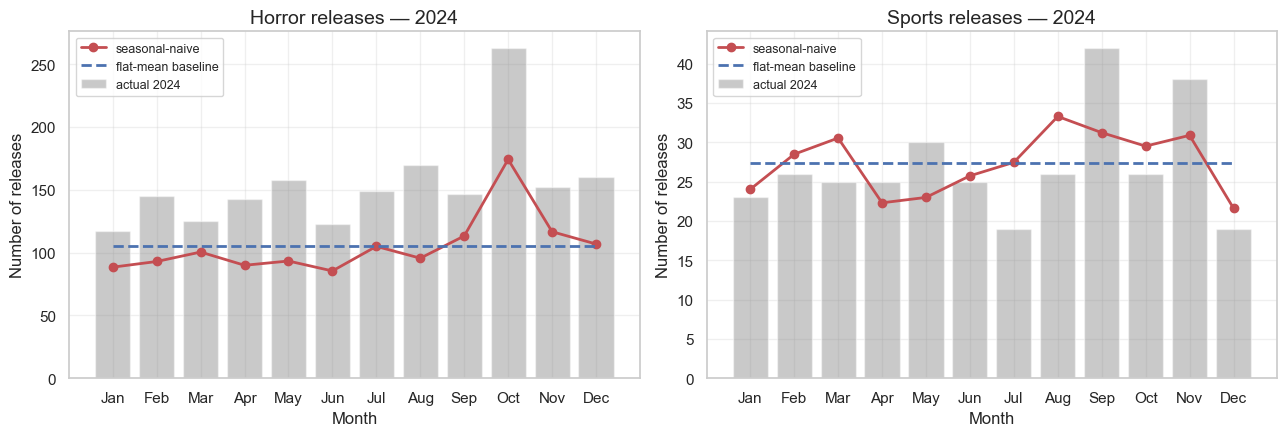

In [58]:
# Test = most recent year. Shape learned from the 3 prior years.
TEST_YEAR        = YEAR_MAX
LAST_TRAIN_YEAR  = TEST_YEAR - 1
SHAPE_YEARS      = [TEST_YEAR - i for i in range(3, 0, -1)]

forecast_rows   = []
forecast_curves = {}

for name, grid in theme_grids.items():
    if TEST_YEAR not in grid.index or LAST_TRAIN_YEAR not in grid.index:
        continue
    actual = grid.loc[TEST_YEAR].to_numpy()
    if actual.sum() == 0:
        continue

    # ---- Shape-only (fractions) comparison: pure seasonality test ----
    actual_frac = actual / actual.sum()                         # 12 fractions, sum=1

    monthly_avg = grid.loc[SHAPE_YEARS].mean(axis=0).to_numpy()
    seasonal_frac = monthly_avg / monthly_avg.sum()             # learned shape, sum=1
    flat_frac     = np.full(12, 1.0 / 12.0)

    # MAE in percentage points (1.0 = "1 percentage point off per month").
    mae_flat_pp     = float(np.mean(np.abs(flat_frac     - actual_frac))) * 100
    mae_seasonal_pp = float(np.mean(np.abs(seasonal_frac - actual_frac))) * 100
    lift            = (mae_flat_pp - mae_seasonal_pp) / mae_flat_pp * 100 \
                      if mae_flat_pp > 0 else 0.0

    # ---- Raw-count predictions for the chart (level x shape) ----
    level = float(grid.loc[LAST_TRAIN_YEAR].mean())
    seasonal_pred_count = level * (monthly_avg / monthly_avg.mean())
    flat_pred_count     = np.full(12, level)

    forecast_rows.append({
        "theme":            name,
        "test_year":        int(TEST_YEAR),
        "test_total":       int(actual.sum()),
        "MAE_flat_pp":      round(mae_flat_pp, 2),
        "MAE_seasonal_pp":  round(mae_seasonal_pp, 2),
        "improvement_%":    round(lift, 1),
    })
    forecast_curves[name] = (actual, seasonal_pred_count, flat_pred_count)

forecast_df = pd.DataFrame(forecast_rows)
print(f"Forecasting {TEST_YEAR} from {SHAPE_YEARS[0]}-{SHAPE_YEARS[-1]}:\n")
print(forecast_df.to_string(index=False))

# Visual: actual vs both forecasts for two illustrative themes.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
plot_themes = ["Horror", "Sports"] if "Sports" in forecast_curves else list(forecast_curves)[:2]

for ax, theme in zip(axes, plot_themes):
    actual, seasonal_pred, flat_pred = forecast_curves[theme]
    ax.bar(range(12), actual, alpha=0.45, color="#888888", label=f"actual {TEST_YEAR}")
    ax.plot(range(12), seasonal_pred, marker="o", color="#C44E52",
            linewidth=2, label="seasonal-naive")
    ax.plot(range(12), flat_pred, color="#4C72B0", linestyle="--",
            linewidth=2, label="flat-mean baseline")
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_title(f"{theme} releases &mdash; {TEST_YEAR}".replace("&mdash;", "—"))
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of releases")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### What we learned

1. **Horror really does spike in October &mdash; and we can prove it.**
   October is the strongest peak in the entire chart (around `1.6&times;`
   the theme's average month) and on the held-out year the seasonal
   forecaster cuts the shape error by **roughly 40%** versus a flat
   baseline. That's the cleanest "yes, there is real and exploitable
   seasonality" result we get out of any theme.

2. **Sports / Racing peak around late summer.** The September spike
   matches the start of major sporting calendars (NFL, FIFA cycles).
   The signal is visually clear in the chart but the seasonal forecaster
   only ties the flat baseline on the held-out year &mdash; the *shape* is
   real, but it shifts a little year-to-year, so naive month-of-year
   averages don't always win.

3. **RPG and Strategy release essentially year-round.** Their seasonal
   index curves stay close to `1.0` all year. The seasonal forecaster
   actually *loses* slightly to flat-mean for these themes &mdash; which is
   the honest answer: there isn't much seasonality to exploit, and
   pretending otherwise just adds noise.

4. **This is seasonality analysis, not full forecasting.** We're
   predicting the typical monthly *share* of releases, not anticipating
   surprise hits, delayed launches, or hot-streak years. The point is to
   show that the Halloween effect is real and measurable &mdash; not to
   build a competitive sales forecaster.

5. **Why this is "simple but credible".** The forecaster has zero tunable
   parameters and a baseline (`1/12` every month) you cannot accidentally
   cheat. When seasonal beats flat (Horror) it's because the signal is
   genuinely strong. When it ties or loses (Sports, RPG, Strategy) we
   report that honestly &mdash; "no usable seasonality" is itself a
   finding.

## 17. Save artifacts

Everything a downstream service (FastAPI / Prefect) needs to serve
recommendations, player-type predictions, popularity regression,
hidden-genre clustering, **and** the seasonality lookup, without
retraining:

| File | What it is |
| ---- | ---------- |
| `catalog.parquet` (or `.pkl` fallback) | The merged Steam+RAWG catalog dataframe (now with a `cluster_id` column) |
| `tfidf_vectorizer.joblib`              | Fitted `TfidfVectorizer` |
| `tfidf_matrix.npz`                     | Sparse TF&#8209;IDF matrix (one row per catalog game) |
| `svd.joblib`                           | Fitted `TruncatedSVD` (for transforming new queries) |
| `lsa_matrix.npy`                       | Pre-computed L2-normalized latent matrix |
| `popularity.npy`                       | Min-max scaled popularity vector |
| `player_type_classifier.joblib`        | Fitted multi&#8209;label `OneVsRestClassifier` |
| `player_types_rules.json`              | Labeling-rule dict (re-runnable weak supervision) |
| `popularity_regressor.joblib`          | XGBoost popularity regressor + meta (year shift constants, extra-feature names) |
| `kmeans_clusters.joblib`               | Fitted `KMeans` model (chosen `k`, centres) |
| `cluster_cards.json`                   | Human-readable hidden-genre cards (auto-name, distinctive tags, examples) |
| `seasonality.json`                     | Per-theme monthly seasonal index + held-out forecast metrics |

A consumer can rebuild the full hybrid recommender + classifier + regressor
+ cluster lookup + seasonal forecaster from these in &lt;1 second without
reading either the Steam CSV or the 4&nbsp;GB RAWG JSONL.

In [ ]:
try:
    catalog_path = ARTIFACTS_DIR / "catalog.parquet"
    catalog.to_parquet(catalog_path, index=False)
    catalog_loader = "pd.read_parquet"
except Exception as e:
    catalog_path = ARTIFACTS_DIR / "catalog.pkl"
    catalog.to_pickle(catalog_path)
    catalog_loader = "pd.read_pickle"
    print(f"  parquet engine unavailable ({type(e).__name__}); saved as pickle instead")

vec_path = ARTIFACTS_DIR / "tfidf_vectorizer.joblib"
joblib.dump(vectorizer, vec_path)

mat_path = ARTIFACTS_DIR / "tfidf_matrix.npz"
sp.save_npz(mat_path, tfidf)

svd_path = ARTIFACTS_DIR / "svd.joblib"
joblib.dump(svd, svd_path)

lsa_path = ARTIFACTS_DIR / "lsa_matrix.npy"
np.save(lsa_path, lsa_norm)

pop_path = ARTIFACTS_DIR / "popularity.npy"
np.save(pop_path, pop_norm)

clf_path = ARTIFACTS_DIR / "player_type_classifier.joblib"
joblib.dump({"clf": player_clf, "labels": PLAYER_TYPE_NAMES}, clf_path)

rules_path = ARTIFACTS_DIR / "player_types_rules.json"
with open(rules_path, "w", encoding="utf-8") as f:
    # JSON can't serialise sets, convert to sorted lists.
    json.dump(
        {k: {kk: sorted(vv) for kk, vv in v.items()} for k, v in PLAYER_TYPES.items()},
        f,
        indent=2,
        ensure_ascii=False,
    )

reg_path = ARTIFACTS_DIR / "popularity_regressor.joblib"
joblib.dump(
    {
        "model": fitted[best_name],
        "model_name": best_name,
        "n_lsa": N_LATENT,
        "year_centre": 2010.0,
        "year_scale": 10.0,
        "median_year": median_year,
        "extra_feature_names": EXTRA_FEATURE_NAMES,
        "metrics": {
            r["model"]: {k: v for k, v in r.items() if k != "model"} for r in results
        },
    },
    reg_path,
)

# --- Clustering artifacts ---
clu_path = ARTIFACTS_DIR / "kmeans_clusters.joblib"
joblib.dump(
    {
        "model": kmeans,
        "k": best_k,
        "names": cluster_names,
    },
    clu_path,
)

cards_path = ARTIFACTS_DIR / "cluster_cards.json"
with open(cards_path, "w", encoding="utf-8") as f:
    # distinctive_tags is a list of (tag, lift, count) tuples; serialise as dicts.
    json_cards = []
    for c in cluster_cards:
        json_cards.append(
            {
                **{k: v for k, v in c.items() if k != "distinctive_tags"},
                "distinctive_tags": [
                    {"tag": t, "lift": round(l, 3), "count": int(n)}
                    for (t, l, n) in c["distinctive_tags"]
                ],
            }
        )
    json.dump(json_cards, f, indent=2, ensure_ascii=False)

# --- Seasonality artifact ---
seasonality_path = ARTIFACTS_DIR / "seasonality.json"
with open(seasonality_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "window": {"year_min": YEAR_MIN, "year_max": YEAR_MAX},
            "test_year": int(TEST_YEAR),
            "themes": {
                name: {
                    "monthly_avg": [
                        round(float(v), 3) for v in theme_grids[name].mean(axis=0)
                    ],
                    "seasonal_index": [
                        round(float(v), 3) for v in seasonal_index[name].values
                    ],
                    "n_games": int(len(theme_dfs[name])),
                }
                for name in THEMES
            },
            "forecast_metrics": forecast_rows,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )


for p in [
    catalog_path,
    vec_path,
    mat_path,
    svd_path,
    lsa_path,
    pop_path,
    clf_path,
    rules_path,
    reg_path,
    clu_path,
    cards_path,
    seasonality_path,
]:
    print(f"  saved {p.relative_to(PROJECT_ROOT)}  ({p.stat().st_size / 1024:.0f} KB)")

print("\nDone. Reload anywhere with:")
print(
    f"  catalog    = {catalog_loader}('{catalog_path.relative_to(PROJECT_ROOT).as_posix()}')"
)
print(f"  vectorizer = joblib.load('{vec_path.relative_to(PROJECT_ROOT).as_posix()}')")
print(
    f"  tfidf      = scipy.sparse.load_npz('{mat_path.relative_to(PROJECT_ROOT).as_posix()}')"
)
print(f"  svd        = joblib.load('{svd_path.relative_to(PROJECT_ROOT).as_posix()}')")
print(f"  lsa_norm   = np.load('{lsa_path.relative_to(PROJECT_ROOT).as_posix()}')")
print(f"  popularity = np.load('{pop_path.relative_to(PROJECT_ROOT).as_posix()}')")
print(
    f"  player_clf = joblib.load('{clf_path.relative_to(PROJECT_ROOT).as_posix()}')['clf']"
)
print(
    f"  pop_reg    = joblib.load('{reg_path.relative_to(PROJECT_ROOT).as_posix()}')['model']"
)
print(
    f"  kmeans     = joblib.load('{clu_path.relative_to(PROJECT_ROOT).as_posix()}')['model']"
)

  parquet engine unavailable (ImportError); saved as pickle instead
  saved artifacts\recommender\catalog.pkl  (226062 KB)
  saved artifacts\recommender\tfidf_vectorizer.joblib  (2138 KB)
  saved artifacts\recommender\tfidf_matrix.npz  (58405 KB)
  saved artifacts\recommender\svd.joblib  (50004 KB)
  saved artifacts\recommender\lsa_matrix.npy  (39540 KB)
  saved artifacts\recommender\popularity.npy  (309 KB)
  saved artifacts\recommender\player_type_classifier.joblib  (13 KB)
  saved artifacts\recommender\player_types_rules.json  (2 KB)
  saved artifacts\recommender\popularity_regressor.joblib  (4850 KB)
  saved artifacts\recommender\kmeans_clusters.joblib  (318 KB)
  saved artifacts\recommender\cluster_cards.json  (16 KB)
  saved artifacts\recommender\seasonality.json  (4 KB)

Done. Reload anywhere with:
  catalog    = pd.read_pickle('artifacts/recommender/catalog.pkl')
  vectorizer = joblib.load('artifacts/recommender/tfidf_vectorizer.joblib')
  tfidf      = scipy.sparse.load_npz('ar